# EverFlavor AI - Data Pipeline Notebook

**Team:** EverGlow  
**Course:** ITAI 2277  
**Project:** EverFlavor AI - Multi-Agent Recipe and Nutrition System  

---

## Project Overview

EverFlavor AI is a multi-agent system designed to create authentic global recipes, track nutritional information, respect dietary restrictions, and help users find specialty ingredient stores. The system targets five cuisine families: **Asian, European, Latin American, African, and Middle Eastern**.

This notebook covers three weeks of work:

| Week | Topic |
|------|-------|
| Week 4 | Data Acquisition - identifying and downloading source datasets |
| Week 5 | Data Preprocessing and Feature Engineering |
| Week 6 | Exploratory Data Analysis and Baseline Model |

---

# WEEK 4 - DATA ACQUISITION

---

## 2.1 Identified Data Sources

This section describes every data source we plan to use for EverFlavor AI. Each source was chosen because it contributes a distinct type of information that supports one or more of our three agents: the Nutritionist Agent, the Chef Agent, and the Sourcing Agent.

---

### 1. Nutritional Data (Calories and Nutrients)

**1a. USDA FoodData Central (official U.S. government)**  
Official U.S. government food database and API. We will use it to retrieve and verify calorie and nutrient information for ingredients used in recipes.  
Website + Free API: https://fdc.nal.usda.gov/

**1b. Open Food Facts (global, crowd-sourced)**  
Global, crowd-sourced food database and API. We will use it as an additional source for nutrition, ingredient, and packaged-food information.  
API Documentation: https://openfoodfacts.github.io/documentation/

---

### 2. Recipe and International Cuisine Data

**2a. Food.com Recipes and User Interactions (Kaggle)**  
This will be our primary recipe dataset. It provides recipe and ingredient data that can be used for preprocessing, exploratory analysis, and model development.  
Kaggle Dataset: https://www.kaggle.com/datasets/shuyangli94/food-com-recipes-and-user-interactions

**2b. CulinaryDB - Structured recipes across 22 world regions**  
This dataset will be used to explore ingredient relationships and cuisine patterns. It may also support the ingredient substitution and flavor-compatibility part of EverFlavor.  
Website: https://cosylab.iiitd.edu.in/culinarydb/

**2c. Hugging Face - Recipes with Nutrition**  
This dataset will provide additional recipe information, including nutrition and diet/health-related information.  
Dataset: https://huggingface.co/datasets/datahiveai/recipes-with-nutrition

---

### 3. Additional Dataset Considered

**RecipeDB - 118,000+ recipes from 74 countries**  
This dataset contains international recipes from many countries. We will keep this as an additional option if more international recipe data is needed after evaluating the selected datasets.  
Website: https://cosylab.iiitd.edu.in/recipedb

---

### 4. Location and Sourcing Data

**Google Places API**  
The Google Places API will be used by the Sourcing Agent to find real specialty grocery stores based on the user's location and cuisine needs.

---

## 2.2 Environment Setup

This notebook runs in **Google Colab** and in a **local Jupyter kernel** (VS Code, Antigravity, or JupyterLab). The same cells work in all of them:

- `%pip install` installs into the Python that runs this notebook. (`!pip` can install into a different Python on a local machine, which leads to `ModuleNotFoundError`.)
- The setup cell in 2.3 detects where the notebook is running, moves to the project folder, and loads secrets from the right place.

Run the two cells below first, and again after every kernel restart.

In [1]:
# Install all required libraries for Weeks 4-6.
# %pip (not !pip) installs into the Python that runs this notebook,
# in Colab and in local kernels (VS Code / Antigravity / JupyterLab).
# Locally you can instead run once in a terminal: pip install -r config/requirements.txt
%pip install -q kaggle kagglehub datasets requests pandas pyarrow matplotlib seaborn scikit-learn

## 2.3 Environment Detection and Folder Structure

This cell adapts the notebook to wherever it is running:

| | Google Colab | VS Code / Antigravity / JupyterLab |
|---|---|---|
| Project folder | `/content` (or a cloned copy of the repo) | The repo folder that contains `notebooks/` and `data/` |
| Secrets | Colab Secrets (key icon in the sidebar) | `config/.env` file in the repo (copy `config/.env.example`) |

It also defines `get_secret(name)`, which every later cell uses to read API keys. It checks Colab Secrets first, then `.env`, then normal environment variables, and it never prints the values.

We organize all data into three standard folders:
- `data/raw` - original, unmodified downloads
- `data/interim` - partially cleaned or transformed data
- `data/processed` - final cleaned and feature-engineered data ready for modeling

Generated data files are listed in `.gitignore`, so large CSVs are never pushed to GitHub.

In [2]:
import os
import sys
import importlib.util
from pathlib import Path

# -------------------------------------------------------
# 1. Where is this notebook running?
# -------------------------------------------------------
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

RUNTIME = "Google Colab" if IN_COLAB else "Local Jupyter (VS Code / Antigravity / JupyterLab)"

# -------------------------------------------------------
# 2. Move to the project folder so every relative path
#    (data/raw, data/processed, config/.env) means the same thing
#    everywhere. Local kernels usually start inside
#    notebooks/, so we walk up to the folder that holds
#    both notebooks/ and data/.
# -------------------------------------------------------
def find_project_root(start):
    """Return the nearest folder at or above `start` with notebooks/ and data/, or None."""
    start = Path(start).resolve()
    for folder in [start, *start.parents]:
        if (folder / "notebooks").is_dir() and (folder / "data").is_dir():
            return folder
    return None

PROJECT_ROOT = find_project_root(Path.cwd())
if PROJECT_ROOT is None and IN_COLAB and Path("/content/The-EverFlavor-AI").is_dir():
    # The repo was cloned into Colab with: !git clone <repo url>
    PROJECT_ROOT = Path("/content/The-EverFlavor-AI")
if PROJECT_ROOT is None:
    # Notebook opened on its own (e.g. Colab straight from GitHub): work in the current folder
    PROJECT_ROOT = Path.cwd()
os.chdir(PROJECT_ROOT)

# -------------------------------------------------------
# 3. Secrets.
# Local runs: read KEY=value lines from config/.env in the
# project folder (.env is in .gitignore, so it is never pushed).
# Values already set in the environment are not replaced,
# and empty values are skipped.
# -------------------------------------------------------
def load_env_file(env_path):
    """Load KEY=value lines from an .env file into os.environ. Returns True if found."""
    if not env_path.is_file():
        return False
    # utf-8-sig also handles files saved by Windows Notepad (which adds a BOM)
    with open(env_path, encoding="utf-8-sig") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#") or "=" not in line:
                continue
            key, value = line.split("=", 1)
            key = key.strip()
            if key.startswith("export "):
                key = key[len("export "):].strip()
            value = value.strip().strip('"').strip("'")
            if value and key not in os.environ:
                os.environ[key] = value
    return True

ENV_FILE_FOUND = load_env_file(PROJECT_ROOT / "config" / ".env")


def get_secret(name):
    """Return a secret by name, or None if it is not set anywhere.

    Order: Colab Secrets (in Colab), then environment variables,
    which include everything loaded from .env.
    """
    if IN_COLAB:
        try:
            from google.colab import userdata
            value = userdata.get(name)
            if value:
                return value
        except Exception:
            # Secret not added, or notebook access not switched on
            pass
    return os.environ.get(name) or None

# Libraries such as kagglehub and Hugging Face read these from
# environment variables, so copy them there if they are set.
for _name in ["HF_TOKEN", "KAGGLE_USERNAME", "KAGGLE_KEY"]:
    if _name not in os.environ:
        _value = get_secret(_name)
        if _value:
            os.environ[_name] = _value

# -------------------------------------------------------
# 4. Create the standard project folder structure
# -------------------------------------------------------
folders = ["data/raw", "data/interim", "data/processed"]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

# -------------------------------------------------------
# 5. Report (secret names only, never their values)
# -------------------------------------------------------
REQUIRED_PACKAGES = {"kagglehub": "kagglehub", "datasets": "datasets", "requests": "requests",
                     "pandas": "pandas", "pyarrow": "pyarrow", "matplotlib": "matplotlib",
                     "seaborn": "seaborn", "scikit-learn": "sklearn"}
missing_packages = [pkg for pkg, module in REQUIRED_PACKAGES.items()
                    if importlib.util.find_spec(module) is None]

print(f"Runtime        : {RUNTIME}")
print(f"Python         : {sys.version.split()[0]}")
print(f"Project folder : {PROJECT_ROOT}")
if not IN_COLAB:
    print(f".env file      : {'found' if ENV_FILE_FOUND else 'not found (copy config/.env.example to config/.env)'}")
for _name in ["USDA_API_KEY", "HF_TOKEN", "KAGGLE_USERNAME", "KAGGLE_KEY"]:
    print(f"  {_name:15s}: {'set' if get_secret(_name) else 'not set'}")
for folder in folders:
    print(f"Folder ready   : {folder}")

if sys.version_info < (3, 10):
    print("\nWARNING: Python 3.10 or newer is required.")
if missing_packages:
    print(f"\nWARNING: missing packages: {', '.join(missing_packages)}")
    print("Run the %pip install cell above, then restart the kernel.")

print("\nEnvironment is set up.")

Folder ready: data/raw
Folder ready: data/interim
Folder ready: data/processed

All project folders are set up.


## 2.4 Data Collection

### Source 1 - USDA FoodData Central

**Source:** https://fdc.nal.usda.gov/

The USDA FoodData Central is the official U.S. government nutrition database. We use the free REST API to look up accurate calorie and nutrient values for individual ingredients. This directly supports the Nutritionist Agent, which needs reliable macro-nutrient data to verify that a recipe meets a user's calorie target.

**API key setup:** The key is stored in Google Colab Secrets (the lock icon in the left sidebar) under the name `USDA_API_KEY`. When the notebook runs outside Colab (VS Code, Antigravity), the same name is read from the local `config/.env` file instead (copy `config/.env.example` to `config/.env`; git ignores it). Either way the key is loaded by `get_secret()` from section 2.3 and is never visible in the notebook code.

In [3]:
import os
import requests
import pandas as pd
import json

# -------------------------------------------------------
# Load the USDA API key with get_secret() from section 2.3.
# In Colab: go to the key icon in the left sidebar, add a
# secret named USDA_API_KEY and switch on notebook access.
# In VS Code / Antigravity: put USDA_API_KEY in config/.env.
# Get a free key from: https://fdc.nal.usda.gov/api-guide.html
# -------------------------------------------------------
USDA_API_KEY = get_secret("USDA_API_KEY")

if not USDA_API_KEY:
    raise RuntimeError(
        "USDA_API_KEY not found. In Colab, add it to Secrets; "
        "locally, add it to config/.env, then re-run the setup cell in 2.3."
    )

# Base URL for the USDA FoodData Central search endpoint
USDA_BASE_URL = "https://api.nal.usda.gov/fdc/v1/foods/search"

def usda_search(query, page_size=5, data_type="Foundation,SR Legacy"):
    """Search the USDA FoodData Central API for a given ingredient.

    Args:
        query (str): The ingredient name to search for.
        page_size (int): Number of results to return.
        data_type (str): Comma-separated USDA data types to search.
            "Foundation,SR Legacy" returns generic raw ingredients
            instead of branded products (plantain, not plantain chips).

    Returns:
        dict: The raw JSON response from the API.

    Raises:
        RuntimeError: If the API returns an error status
            (for example 403 for an invalid key).
    """
    params = {
        "api_key": USDA_API_KEY,  # Use the variable, never paste the key directly
        "query": query,
        "pageSize": page_size,
        "dataType": data_type,
    }
    response = requests.get(USDA_BASE_URL, params=params, timeout=15)
    if not response.ok:
        # Do not use raise_for_status() here: its message contains the
        # full request URL, which would print the API key in the output.
        raise RuntimeError(f"USDA API request failed with HTTP {response.status_code}")
    return response.json()

# --- Test the API with a representative ingredient ---
data = usda_search("chicken breast", page_size=3)

print("API request succeeded.")
print("Total hits  :", data.get("totalHits"))
if data.get("foods"):
    print("First result:", data["foods"][0]["description"])
else:
    print("First result: none returned")

Status code : 200
Total hits  : 21661
First result: CHICKEN BREAST


In [4]:
# ---------------------------------------------------------
# Collect a small multi-ingredient sample and save it to
# data/raw so we have a reference for later notebooks.
# ---------------------------------------------------------
test_ingredients = [
    "chicken breast",
    "basmati rice",
    "olive oil",
    "chickpeas",
    "coconut milk",
    "plantain",
    "miso paste",
    "tahini"
]

# USDA reports energy under several names, and some entries are in kJ.
# We only accept kcal values, in this order of preference.
ENERGY_NAMES = ["Energy", "Energy (Atwater General Factors)", "Energy (Atwater Specific Factors)"]

def get_energy_kcal(food_nutrients):
    """Return the energy value in kcal, or None if no kcal value is listed."""
    kcal_values = {
        n.get("nutrientName"): n.get("value")
        for n in food_nutrients
        if str(n.get("unitName", "")).upper() == "KCAL"
    }
    for name in ENERGY_NAMES:
        if name in kcal_values:
            return kcal_values[name]
    return None

records = []
for ingredient in test_ingredients:
    result = usda_search(ingredient, page_size=1)
    if not result.get("foods"):
        print(f"  No USDA match for '{ingredient}'")
        continue
    food = result["foods"][0]
    food_nutrients = food.get("foodNutrients", [])
    # Pull out the key nutrient fields we care about
    nutrients = {n.get("nutrientName"): n.get("value") for n in food_nutrients}
    records.append({
        "query"      : ingredient,
        "fdc_id"     : food.get("fdcId"),
        "description": food.get("description"),
        "data_type"  : food.get("dataType"),
        "calories"   : get_energy_kcal(food_nutrients),
        "protein_g"  : nutrients.get("Protein"),
        "fat_g"      : nutrients.get("Total lipid (fat)"),
        "carbs_g"    : nutrients.get("Carbohydrate, by difference")
    })

usda_sample = pd.DataFrame(records)
usda_sample.to_csv("data/raw/usda_sample.csv", index=False)

print(f"Saved {len(usda_sample)} ingredient records to data/raw/usda_sample.csv")
print()
# Show the matched description so we can confirm USDA picked the right food
print(usda_sample[["query", "description", "calories", "protein_g", "fat_g", "carbs_g"]].to_string(index=False))

Saved 8 ingredient records to data/raw/usda_sample.csv

            query  calories  protein_g   fat_g  carbs_g
0  chicken breast       165      20.40    8.10     1.06
1    basmati rice       333       8.89    0.00    84.40
2       olive oil       900       0.00  100.00     0.00
3       chickpeas       128       8.00    1.60    20.80
4    coconut milk        31       0.21    2.08     2.92
5        plantain       531       2.28   29.59    63.84
6      miso paste       167      11.10    5.56    22.20
7          tahini       697      19.71   62.40    14.18


### Source 2 - Food.com Recipes and User Interactions (Kaggle)

**Source:** https://www.kaggle.com/datasets/shuyangli94/food-com-recipes-and-user-interactions

This is our **primary recipe dataset**. It contains over 230,000 recipes with ingredient lists, step-by-step instructions, nutritional summaries, and user interaction data. We will use it for preprocessing, exploratory analysis, and as the primary training corpus for the Chef Agent. The dataset also includes a pre-processed version (`PP_recipes.csv`) with tokenized ingredients, which will be useful for feature engineering.

In [5]:
import kagglehub

# Download the Food.com dataset via kagglehub.
# On the first run this may take a few minutes depending on network speed.
# On subsequent runs it reads from the local cache.
try:
    path = kagglehub.dataset_download("shuyangli94/food-com-recipes-and-user-interactions")
except Exception as e:
    raise RuntimeError(
        "Kaggle download failed. If the error mentions credentials, add KAGGLE_USERNAME "
        "and KAGGLE_KEY (Colab Secrets or .env), re-run the setup cell in 2.3, then retry. "
        f"Original error: {e}"
    ) from e

print("Path to dataset files:", path)
print("\nFiles inside the folder:")
print(os.listdir(path))

100%|██████████| 267M/267M [00:01<00:00, 163MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/shuyangli94/food-com-recipes-and-user-interactions/versions/2

Files inside the folder:
['ingr_map.pkl', 'interactions_train.csv', 'interactions_test.csv', 'RAW_interactions.csv', 'RAW_recipes.csv', 'PP_users.csv', 'PP_recipes.csv', 'interactions_validation.csv']


In [6]:
import pandas as pd

# Load the raw recipe file
recipes_raw = pd.read_csv(f"{path}/RAW_recipes.csv")

print("Shape (rows, columns):", recipes_raw.shape)
print("\nColumn names:")
print(list(recipes_raw.columns))
print()
recipes_raw.head(3)

Shape (rows, columns): (231637, 12)

Column names:
['name', 'id', 'minutes', 'contributor_id', 'submitted', 'tags', 'nutrition', 'n_steps', 'steps', 'description', 'ingredients', 'n_ingredients']



,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"['30-minutes-or-less', 'time-to-make', 'course...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"['preheat oven to 425 degrees f', 'press dough...",this recipe calls for the crust to be prebaked...,"['prepared pizza crust', 'sausage patty', 'egg...",6
2,all in the kitchen chili,112140,130,196586,2005-02-25,"['time-to-make', 'course', 'preparation', 'mai...","[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]",6,"['brown ground beef in large pot', 'add choppe...",this modified version of 'mom's' chili was a h...,"['ground beef', 'yellow onions', 'diced tomato...",13


In [7]:
# Walk the dataset folder to confirm all files are present
print("All files in the Food.com dataset folder:")
for root, dirs, files in os.walk(path):
    for file in files:
        print(" ", os.path.join(root, file))

All files in the Food.com dataset folder:
  /root/.cache/kagglehub/datasets/shuyangli94/food-com-recipes-and-user-interactions/versions/2/ingr_map.pkl
  /root/.cache/kagglehub/datasets/shuyangli94/food-com-recipes-and-user-interactions/versions/2/interactions_train.csv
  /root/.cache/kagglehub/datasets/shuyangli94/food-com-recipes-and-user-interactions/versions/2/interactions_test.csv
  /root/.cache/kagglehub/datasets/shuyangli94/food-com-recipes-and-user-interactions/versions/2/RAW_interactions.csv
  /root/.cache/kagglehub/datasets/shuyangli94/food-com-recipes-and-user-interactions/versions/2/RAW_recipes.csv
  /root/.cache/kagglehub/datasets/shuyangli94/food-com-recipes-and-user-interactions/versions/2/PP_users.csv
  /root/.cache/kagglehub/datasets/shuyangli94/food-com-recipes-and-user-interactions/versions/2/PP_recipes.csv
  /root/.cache/kagglehub/datasets/shuyangli94/food-com-recipes-and-user-interactions/versions/2/interactions_validation.csv


In [8]:
# Save a 1,000-row sample to data/raw for quick reference in later notebooks
recipes_raw.head(1000).to_csv("data/raw/food_com_sample.csv", index=False)
print("Saved 1,000-row Food.com sample to data/raw/food_com_sample.csv")

Saved 1,000-row Food.com sample to data/raw/food_com_sample.csv


### Source 3 - Hugging Face - Recipes with Nutrition

**Source:** https://huggingface.co/datasets/datahiveai/recipes-with-nutrition

This dataset provides approximately 39,000 recipes that already include structured nutrition information, diet labels (such as Balanced or Low-Fat), health labels (such as Vegetarian, Gluten-Free), and cuisine type. It is useful for enriching our recipe data and for testing how well our Nutritionist Agent can classify and verify recipes.

In [9]:
from datasets import load_dataset

# Load the full training split from Hugging Face.
# This will download ~450 MB on the first run.
hf_dataset = load_dataset("datahiveai/recipes-with-nutrition", split="train")

print("Dataset info:")
print(hf_dataset)
print("\nAvailable columns:")
print(list(hf_dataset.features.keys()))

README.md:   0%|          | 0.00/2.63k [00:00<?, ?B/s]

recipes-with-nutrition.csv: reconstructing file:   0%|          |  0.00B /  450MB            

recipes-with-nutrition.csv: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/39447 [00:00<?, ? examples/s]

Dataset info:
Dataset({
    features: ['recipe_name', 'source', 'url', 'servings', 'calories', 'total_weight_g', 'image_url', 'diet_labels', 'health_labels', 'cautions', 'cuisine_type', 'meal_type', 'dish_type', 'ingredient_lines', 'ingredients', 'total_nutrients', 'daily_values', 'digest'],
    num_rows: 39447
})

Available columns:
['recipe_name', 'source', 'url', 'servings', 'calories', 'total_weight_g', 'image_url', 'diet_labels', 'health_labels', 'cautions', 'cuisine_type', 'meal_type', 'dish_type', 'ingredient_lines', 'ingredients', 'total_nutrients', 'daily_values', 'digest']


In [10]:
# Convert to a pandas DataFrame for easier exploration
hf_df = hf_dataset.to_pandas()

print("Shape:", hf_df.shape)
print()

# Show a few key columns so we know what we are working with
preview_cols = ["recipe_name", "calories", "cuisine_type", "diet_labels", "health_labels"]
print(hf_df[preview_cols].head(5).to_string())

Shape: (39447, 18)

                                                   recipe_name     calories          cuisine_type                diet_labels                                                                                                  health_labels
0       Classic Cabbage Slaw with Grandmother Shinn's Dressing   511.283250          ["american"]               ["Balanced"]             ["Vegetarian","Gluten-Free","Peanut-Free","Tree-Nut-Free","Soy-Free","Fish-Free","Shellfish-Free"]
1                                              Black Bean Soup  1850.998990          ["american"]             ["High-Fiber"]  ["Dairy-Free","Gluten-Free","Egg-Free","Peanut-Free","Tree-Nut-Free","Soy-Free","Fish-Free","Shellfish-Free"]
2  Eat for Eight Bucks: Tofu with Tomatoes and Cilantro Recipe  1643.758565             ["asian"]  ["High-Fiber","Low-Carb"]                    ["Vegan","Vegetarian","Dairy-Free","Egg-Free","Tree-Nut-Free","Fish-Free","Shellfish-Free"]
3                                   

In [11]:
# Save a 1,000-row sample to data/raw
hf_df.head(1000).to_csv("data/raw/hf_recipes_sample.csv", index=False)
print("Saved 1,000-row Hugging Face sample to data/raw/hf_recipes_sample.csv")

Saved 1,000-row Hugging Face sample to data/raw/hf_recipes_sample.csv


### Source 4 - Open Food Facts (Global, Crowd-Sourced)

**Source:** https://openfoodfacts.github.io/documentation/  
**License:** Open Database License (ODbL) - free to use, share, and adapt with attribution  
**No API key required.**

Open Food Facts is a global, community-driven food database containing over 3 million products from more than 170 countries. It is especially useful for EverFlavor AI because:

- It covers **packaged and specialty ingredients** commonly found in international recipes (miso paste, tahini, harissa, coconut milk brands, etc.).
- Each product record includes **ingredient lists, allergen flags, nutrition facts per 100g, Nutri-Score, and NOVA group** (level of food processing).
- The data is updated continuously by volunteers worldwide, making it a living supplement to the USDA database.

**How we use it in EverFlavor AI:**

| Agent | Use Case |
|-------|----------|
| Nutritionist Agent | Cross-check calorie and macro data for packaged ingredients not in the USDA database |
| Chef Agent | Retrieve ingredient lists and allergen tags for authenticity and safety checks |
| Sourcing Agent | Look up brand names and country of origin to help users find specific products |

**API endpoints used in this notebook:**

| Endpoint | Purpose |
|----------|---------|
| `/cgi/search.pl` | Full-text product search by ingredient or product name |
| `/api/v2/product/{barcode}.json` | Fetch a single product by its barcode |

The five cells below are fully runnable. They will connect to the live Open Food Facts API, retrieve real product data, run a quality check, and save a sample CSV to `data/raw/`.

In [12]:
import requests
import pandas as pd
import time

# -------------------------------------------------------
# Open Food Facts helper functions.
# No API key is required. The API is free and public.
# -------------------------------------------------------

OFF_BASE_URL = "https://world.openfoodfacts.org"

# Open Food Facts asks every client to send a descriptive User-Agent.
# Requests without one can be blocked with 403 Forbidden.
OFF_HEADERS = {
    "User-Agent": "EverFlavorAI - Colab Academic Project - Version 1.0 (contact: team@everglow.com)"
}

# Status codes that mean "try again later" (rate limit or server busy)
OFF_RETRY_STATUS = {429, 500, 502, 503, 504}


def off_get(url, params=None, retries=3, backoff=2.0):
    """GET a URL from Open Food Facts and return the JSON body.

    Temporary failures (rate limits, 5xx errors, timeouts) are retried
    with an increasing wait. Any other error is raised.

    Args:
        url (str): Full endpoint URL.
        params (dict | None): Query parameters.
        retries (int): Maximum number of attempts.
        backoff (float): Seconds to wait after the first failure;
            the wait grows with each attempt.

    Returns:
        dict: The parsed JSON response.
    """
    for attempt in range(1, retries + 1):
        try:
            response = requests.get(url, params=params, headers=OFF_HEADERS, timeout=15)
        except (requests.ConnectionError, requests.Timeout):
            if attempt == retries:
                raise
            time.sleep(backoff * attempt)
            continue
        if response.status_code in OFF_RETRY_STATUS and attempt < retries:
            time.sleep(backoff * attempt)
            continue
        response.raise_for_status()
        return response.json()


def off_search(query, page_size=5):
    """Search Open Food Facts for products matching a query string.

    Only returns products that already have completed nutrition facts,
    so every result will have at least a calorie value.

    Args:
        query (str): Ingredient or product name to search for.
        page_size (int): Maximum number of results to return.

    Returns:
        list[dict]: List of raw product dictionaries from the API.
    """
    url = f"{OFF_BASE_URL}/cgi/search.pl"
    params = {
        "search_terms"   : query,
        "search_simple"  : 1,
        "action"         : "process",
        "json"           : 1,
        "page_size"      : page_size,
        # Only return products with completed nutrition facts
        "tagtype_0"      : "states",
        "tag_contains_0" : "contains",
        "tag_0"          : "en:nutrition-facts-completed",
    }
    return off_get(url, params=params).get("products", [])


def off_get_by_barcode(barcode):
    """Fetch a single product record from Open Food Facts by barcode.

    Args:
        barcode (str): The product barcode (EAN-13 or UPC).

    Returns:
        dict | None: The product dictionary, or None if not found.
    """
    url = f"{OFF_BASE_URL}/api/v2/product/{barcode}.json"
    try:
        data = off_get(url)
    except requests.HTTPError as e:
        # The API answers 404 for barcodes it does not know
        if e.response is not None and e.response.status_code == 404:
            return None
        raise
    if data.get("status") == 1:
        return data.get("product")
    return None


def extract_off_record(product):
    """Pull the fields we need from a raw Open Food Facts product dict.

    Fields: product_name, brands, countries, ingredients_text,
    energy_kcal_100g, proteins_100g, fat_100g, carbs_100g,
    fiber_100g, sodium_100g, nutriscore_grade, nova_group,
    allergens, image_url.

    Text fields that are missing come back as an empty string.

    Args:
        product (dict): A raw product dictionary from the OFF API.

    Returns:
        dict: A flat dictionary of cleaned fields.
    """
    nut = product.get("nutriments") or {}
    # OFF uses "unknown" or "not-applicable" when there is no score.
    # We store those as "" so they are counted as missing.
    grade = (product.get("nutriscore_grade") or "").upper()
    return {
        "product_name"     : (product.get("product_name") or "").strip(),
        "brands"           : product.get("brands") or "",
        "countries"        : product.get("countries") or "",
        "ingredients_text" : product.get("ingredients_text") or "",
        # All nutrition values are per 100 g of product
        "energy_kcal_100g" : nut.get("energy-kcal_100g"),
        "proteins_100g"    : nut.get("proteins_100g"),
        "fat_100g"         : nut.get("fat_100g"),
        "carbs_100g"       : nut.get("carbohydrates_100g"),
        "fiber_100g"       : nut.get("fiber_100g"),
        "sodium_100g"      : nut.get("sodium_100g"),
        # Nutri-Score: A (best) to E (worst)
        "nutriscore_grade" : grade if grade in {"A", "B", "C", "D", "E"} else "",
        # NOVA group: 1 (unprocessed) to 4 (ultra-processed)
        "nova_group"       : product.get("nova_group"),
        "allergens"        : product.get("allergens") or "",
        "image_url"        : product.get("image_url") or "",
    }


print("Open Food Facts helper functions are ready.")
print("  off_search()          - search by ingredient or product name")
print("  off_get_by_barcode()  - fetch one product by barcode")
print("  extract_off_record()  - flatten a raw product dict into clean fields")

Open Food Facts helper functions are ready.
  off_search()          - search by ingredient or product name
  off_get_by_barcode()  - fetch one product by barcode
  extract_off_record()  - flatten a raw product dict into clean fields


In [14]:
# -------------------------------------------------------
# Search for specialty ingredients from each of our five
# target cuisine families and collect the results.
# -------------------------------------------------------

off_queries = [
    ("miso paste",      "Asian"),
    ("tahini",          "Middle Eastern"),
    ("harissa",         "African"),
    ("coconut milk",    "Asian"),
    ("plantain chips",  "Latin American"),
    ("ghee",            "Asian"),
    ("gochujang",       "Asian"),
    ("preserved lemon", "Middle Eastern"),
]

off_records = []

for query, cuisine_family in off_queries:
    try:
        # off_search sends the User-Agent header and retries temporary errors
        products = off_search(query, page_size=3)
    except Exception as e:
        print(f"  Warning: query '{query}' failed - {e}")
        continue

    for p in products:
        record = extract_off_record(p)
        # Skip records missing a product name or calorie data
        if not record["product_name"] or record["energy_kcal_100g"] is None:
            continue
        record["search_query"]   = query
        record["cuisine_family"] = cuisine_family
        off_records.append(record)
    # Pause briefly between requests to be respectful of the public API
    time.sleep(0.5)

off_df = pd.DataFrame(off_records)

print(f"Retrieved {len(off_df)} product records from Open Food Facts.")

if not off_df.empty:
    print(f"Queries with at least one result: {off_df['search_query'].nunique()} of {len(off_queries)}")
    print()

    # Show a concise preview of the most important columns
    preview_cols = [
        "search_query", "product_name", "energy_kcal_100g",
        "proteins_100g", "fat_100g", "carbs_100g", "nutriscore_grade"
    ]
    print(off_df[preview_cols].to_string(index=False))
else:
    print("No records found. The DataFrame is empty due to API errors.")

Retrieved 14 product records from Open Food Facts.
Queries with at least one result: 5

   search_query                                  product_name  energy_kcal_100g  proteins_100g   fat_100g  carbs_100g nutriscore_grade
     miso paste                            Organic Miso Paste        176.000000      11.000000   6.700000   16.000000                E
     miso paste              Wakame Miso Soup Paste 5 Sachets        100.000000       7.100000   3.600000   16.000000          UNKNOWN
     miso paste                 Mellow yellow miso soup paste         12.000000       0.900000   0.500000    0.900000                C
 plantain chips          Plantain Chips (Yellow Banana Chips)        535.714286       3.571429  28.571429   64.285714                E
 plantain chips                           Plantain Chips Salt        566.666667       4.000000  33.333333   60.000000                D
 plantain chips                Plantain Chips Naturally Sweet        496.000000       2.500000  25.100

In [16]:
# -------------------------------------------------------
# Barcode lookup example.
# Barcode 3270160052066 is Maille Dijon Originale mustard,
# a European condiment widely available internationally
# and a good test case for the Sourcing Agent.
# -------------------------------------------------------

sample_barcode = "3270160052066"
try:
    product = off_get_by_barcode(sample_barcode)
except Exception as e:
    print(f"API request failed: {e}")
    product = None

if product:
    rec = extract_off_record(product)
    print(f"Barcode lookup result for {sample_barcode}:")
    print(f"  Product name  : {rec['product_name']}")
    print(f"  Brand         : {rec['brands']}")
    print(f"  Countries     : {rec['countries']}")
    print(f"  Energy        : {rec['energy_kcal_100g']} kcal / 100 g")
    print(f"  Protein       : {rec['proteins_100g']} g / 100 g")
    print(f"  Fat           : {rec['fat_100g']} g / 100 g")
    print(f"  Carbs         : {rec['carbs_100g']} g / 100 g")
    print(f"  Nutri-Score   : {rec['nutriscore_grade'] or 'not available'} (A = best, E = worst)")
    print(f"  NOVA group    : {rec['nova_group']} (1 = unprocessed, 4 = ultra-processed)")
    print(f"  Allergens     : {rec['allergens']}")
else:
    print(f"Product with barcode {sample_barcode} was not found or could not be loaded from Open Food Facts.")

API request failed: 404 Client Error: Not Found for url: https://world.openfoodfacts.org/api/v2/product/3270160052066.json
Product with barcode 3270160052066 was not found or could not be loaded from Open Food Facts.


In [17]:
# -------------------------------------------------------
# Quality check on the Open Food Facts sample
# -------------------------------------------------------

if not off_df.empty:
    print("=== Open Food Facts Sample - Quality Report ===")
    print(f"Total records          : {len(off_df)}")
    print(f"Missing energy_kcal    : {off_df['energy_kcal_100g'].isna().sum()}")
    # extract_off_record stores "unknown" / "not-applicable" scores as ""
    print(f"Missing Nutri-Score    : {(off_df['nutriscore_grade'] == '').sum()}")
    print(f"Missing ingredient txt : {(off_df['ingredients_text'] == '').sum()}")
    print()
    print("Nutri-Score distribution:")
    print(off_df["nutriscore_grade"].replace("", "(missing)").value_counts().to_string())
    print()
    print("Calorie range (kcal per 100 g):")
    print(off_df["energy_kcal_100g"].describe().round(1).to_string())
    print()
    print("Results by cuisine family:")
    print(off_df["cuisine_family"].value_counts().to_string())
else:
    print("OFF dataframe is empty. Check your network connection and try again.")

=== Open Food Facts Sample - Quality Report ===
Total records          : 14
Missing energy_kcal    : 0
Missing Nutri-Score    : 0
Missing ingredient txt : 1

Nutri-Score distribution:
nutriscore_grade
E                 9
NOT-APPLICABLE    2
UNKNOWN           1
C                 1
D                 1

Calorie range (kcal per 100 g):
count     14.0
mean     339.1
std      300.3
min       12.0
25%      119.0
50%      224.5
75%      525.8
max      900.0

Results by cuisine family:
cuisine_family
Asian             8
Latin American    3
Middle Eastern    3


In [18]:
# -------------------------------------------------------
# Save the Open Food Facts sample to data/raw
# -------------------------------------------------------

if not off_df.empty:
    off_df.to_csv("data/raw/open_food_facts_sample.csv", index=False)
    print(f"Saved {len(off_df)} records to data/raw/open_food_facts_sample.csv")
    print()
    print("Column completeness summary:")
    for col in off_df.columns:
        # Empty strings count as missing, not only NaN / None
        filled = off_df[col].notna() & (off_df[col].astype(str).str.strip() != "")
        non_null = filled.sum()
        pct      = non_null / len(off_df) * 100
        print(f"  {col:22s} {non_null:>4}/{len(off_df)} ({pct:.0f}% complete)")
else:
    print("Nothing to save. The dataframe is empty.")

Saved 14 records to data/raw/open_food_facts_sample.csv

Column completeness summary:
  product_name             14/14 (100% complete)
  brands                   14/14 (100% complete)
  countries                14/14 (100% complete)
  ingredients_text         14/14 (100% complete)
  energy_kcal_100g         14/14 (100% complete)
  proteins_100g            14/14 (100% complete)
  fat_100g                 14/14 (100% complete)
  carbs_100g               14/14 (100% complete)
  fiber_100g               10/14 (71% complete)
  sodium_100g              14/14 (100% complete)
  nutriscore_grade         14/14 (100% complete)
  nova_group                9/14 (64% complete)
  allergens                14/14 (100% complete)
  image_url                14/14 (100% complete)
  search_query             14/14 (100% complete)
  cuisine_family           14/14 (100% complete)


### Source 5 - Additional Datasets (Not Used in This Notebook Yet)

**CulinaryDB - Structured recipes across 22 world regions**  
https://cosylab.iiitd.edu.in/culinarydb/  
This dataset will be used later to explore ingredient relationships and cuisine patterns. It may also support the ingredient substitution and flavor-compatibility features of EverFlavor.

**RecipeDB - 118,000+ recipes from 74 countries**  
https://cosylab.iiitd.edu.in/recipedb  
Kept as an additional option if more international recipe data is needed after evaluating the selected datasets.

**Google Places API**  
Will be integrated in the Sourcing Agent module. It will use the user's location to recommend nearby specialty grocery stores that carry ingredients for the chosen cuisine.

## 2.5 Privacy and Ethics Note

All datasets used in this project are publicly available and were obtained through official channels (USDA government API, Kaggle, and Hugging Face). No personally identifiable information (PII) is collected or stored as part of the EverFlavor AI data pipeline.

- **USDA FoodData Central** is a public government database. No PII is involved.
- **Food.com** data from Kaggle contains anonymized user IDs only. We do not use user identifiers in our models.
- **Hugging Face - Recipes with Nutrition** contains recipe and nutrition data. No user data is present.
- **Open Food Facts** is crowd-sourced and publicly licensed under the Open Database License (ODbL). Contributor identities are not used.

API keys (USDA now; Google Places and Groq later) are never written in the notebook code. They are read from Colab Secrets or from a local `.env` file that git ignores, so they are never pushed to GitHub.

When we integrate the **Google Places API** in the Sourcing Agent, user location data will be used only in real time to generate store recommendations and will not be stored or shared.

The team commits to following responsible AI practices: being transparent about data sources, avoiding bias in cuisine representation where possible, and clearly communicating limitations of the model to end users.

---

# WEEK 5 - DATA PREPROCESSING AND FEATURE ENGINEERING

In this section we take the raw data collected in Week 4 and transform it into a clean, analysis-ready dataset. The goals are:

1. Assess data quality (missing values, duplicates, inconsistent units, outliers)
2. Engineer features that the three EverFlavor agents will actually use
3. Build a simple transformation pipeline
4. Split the data into train, validation, and test sets

---

## 5.1 Load the Raw Datasets

We reload the full Food.com and Hugging Face datasets. If you start this section after a kernel restart, run the setup cells in 2.2 and 2.3 first. Run the Week 4 download cells too, so that `path` and `hf_df` are defined; otherwise the 1,000-row samples in `data/raw` are used and the cell prints a warning.

In [19]:
import pandas as pd
import numpy as np
import ast
import json
import re
import os
import warnings
warnings.filterwarnings("ignore")

# The setup cell in 2.3 moves to the project folder; without it,
# the data/ paths below point to the wrong place after a restart.
if "PROJECT_ROOT" not in globals():
    raise RuntimeError("Run the setup cell in section 2.3 first (it is needed after every kernel restart).")

# Recipes above this many kcal per serving are treated as data errors
# (used for both datasets in the cleaning steps below)
MAX_KCAL_PER_SERVING = 3000

# ------------------------------------------------------------------
# Reload Food.com raw recipes
# (If `path` is not defined run the Week 4 kagglehub cell first)
# ------------------------------------------------------------------
try:
    recipes_raw = pd.read_csv(f"{path}/RAW_recipes.csv")
    print("Food.com loaded from kagglehub path.")
except NameError:
    recipes_raw = pd.read_csv("data/raw/food_com_sample.csv")
    print("WARNING: Food.com loaded from the saved 1,000-row sample, not the full dataset.")
    print("         Run the Week 4 kagglehub cell first for full results.")

# ------------------------------------------------------------------
# Reload Hugging Face recipes
# ------------------------------------------------------------------
try:
    _ = hf_df
    print("Hugging Face dataset already in memory.")
except NameError:
    hf_df = pd.read_csv("data/raw/hf_recipes_sample.csv")
    print("WARNING: Hugging Face loaded from the saved 1,000-row sample, not the full dataset.")
    print("         Run the Week 4 Hugging Face cell first for full results.")

print(f"\nFood.com shape : {recipes_raw.shape}")
print(f"HF shape       : {hf_df.shape}")

Food.com loaded from kagglehub path.
Hugging Face dataset already in memory.

Food.com shape : (231637, 12)
HF shape       : (39447, 18)


## 5.2 Data Quality Assessment

Before we can engineer features, we need to understand what is in our data. We look at:

- **Missing values** - which columns have gaps and how severe are they?
- **Duplicates** - are there repeated recipes that could bias our analysis?
- **Inconsistent units** - calorie values need to be in kcal; quantities need to be numeric.
- **Outliers** - extreme calorie values or cook times that look like data entry errors.

In [20]:
# -------------------------------------------------------
# Missing value analysis for the Food.com dataset
# -------------------------------------------------------
missing = recipes_raw.isnull().sum()
missing_pct = (missing / len(recipes_raw) * 100).round(2)

quality_report = pd.DataFrame({
    "missing_count": missing,
    "missing_pct"  : missing_pct
}).sort_values("missing_pct", ascending=False)

print("=== Food.com Missing Value Report ===")
print(quality_report.to_string())
print(f"\nTotal rows       : {len(recipes_raw):,}")
print(f"Duplicate rows   : {recipes_raw.duplicated().sum():,}")

=== Food.com Missing Value Report ===
                missing_count  missing_pct
description              4979         2.15
name                        1         0.00
minutes                     0         0.00
id                          0         0.00
contributor_id              0         0.00
submitted                   0         0.00
nutrition                   0         0.00
tags                        0         0.00
n_steps                     0         0.00
steps                       0         0.00
ingredients                 0         0.00
n_ingredients               0         0.00

Total rows       : 231,637
Duplicate rows   : 0


In [21]:
# -------------------------------------------------------
# Missing value analysis for the Hugging Face dataset
# -------------------------------------------------------
hf_missing = hf_df.isnull().sum()
hf_missing_pct = (hf_missing / len(hf_df) * 100).round(2)

hf_quality = pd.DataFrame({
    "missing_count": hf_missing,
    "missing_pct"  : hf_missing_pct
}).sort_values("missing_pct", ascending=False)

print("=== Hugging Face Missing Value Report ===")
print(hf_quality.to_string())
print(f"\nTotal rows       : {len(hf_df):,}")
print(f"Duplicate rows   : {hf_df.duplicated().sum():,}")

=== Hugging Face Missing Value Report ===
                  missing_count  missing_pct
image_url                   277          0.7
recipe_name                   0          0.0
source                        0          0.0
url                           0          0.0
calories                      0          0.0
servings                      0          0.0
total_weight_g                0          0.0
diet_labels                   0          0.0
health_labels                 0          0.0
cautions                      0          0.0
cuisine_type                  0          0.0
meal_type                     0          0.0
dish_type                     0          0.0
ingredient_lines              0          0.0
ingredients                   0          0.0
total_nutrients               0          0.0
daily_values                  0          0.0
digest                        0          0.0

Total rows       : 39,447
Duplicate rows   : 0


In [22]:
# -------------------------------------------------------
# Outlier check - calories per serving in both datasets
# -------------------------------------------------------

# Hugging Face 'calories' is the total for the whole recipe,
# so we divide by 'servings' to get a per-serving value.
hf_servings = pd.to_numeric(hf_df["servings"], errors="coerce")
hf_servings = hf_servings.where(hf_servings > 0)
hf_kcal_per_serving = hf_df["calories"] / hf_servings

print("Whole-recipe calories (Hugging Face):")
print(hf_df["calories"].describe())
print("\nCalories per serving (Hugging Face):")
print(hf_kcal_per_serving.describe())
print(f"\nRows with missing or zero servings          : {hf_servings.isna().sum()}")
print(f"Rows with > {MAX_KCAL_PER_SERVING:,} kcal per serving          : {(hf_kcal_per_serving > MAX_KCAL_PER_SERVING).sum()}")

# Food.com calories are the first value of the 'nutrition' list
# and are already per serving.
fc_kcal_per_serving = pd.to_numeric(
    recipes_raw["nutrition"].str.strip("[]").str.split(",").str[0],
    errors="coerce"
)
print("\nCalories per serving (Food.com):")
print(fc_kcal_per_serving.describe())
print(f"Rows with > {MAX_KCAL_PER_SERVING:,} kcal per serving          : {(fc_kcal_per_serving > MAX_KCAL_PER_SERVING).sum()}")

# Check cook-time outliers in Food.com
print("\nCook time (minutes) distribution (Food.com):")
print(recipes_raw["minutes"].describe())
unrealistic = (recipes_raw["minutes"] > 1440).sum()  # more than 24 hours
print(f"Recipes with cook time > 24 hours : {unrealistic}")

Calorie distribution (Hugging Face):
count    39447.000000
mean      2139.060923
std       1924.697195
min          0.060000
25%        866.158614
50%       1656.948000
75%       2817.372416
max      33319.350000
Name: calories, dtype: float64

Rows with calories >= 10,000 kcal : 297

Cook time (minutes) distribution (Food.com):
count    2.316370e+05
mean     9.398546e+03
std      4.461963e+06
min      0.000000e+00
25%      2.000000e+01
50%      4.000000e+01
75%      6.500000e+01
max      2.147484e+09
Name: minutes, dtype: float64
Recipes with cook time > 24 hours : 2000


## 5.3 Data Cleaning

Based on the quality report above, we apply targeted cleaning steps:

1. Drop rows with missing recipe names, ingredient lists, calories, or servings.
2. Remove duplicate recipes.
3. Convert Hugging Face calories from whole-recipe totals to calories per serving.
4. Remove recipes above 3,000 kcal per serving (both datasets; Food.com is filtered in 5.4.3 once its nutrition column is parsed).
5. Remove recipes with unrealistically long cook times.

In [23]:
# -------------------------------------------------------
# Clean the Food.com dataset
# -------------------------------------------------------
df_fc = recipes_raw.copy()

# Step 1: Drop rows missing essential fields
before = len(df_fc)
df_fc = df_fc.dropna(subset=["name", "ingredients", "nutrition"])
print(f"Dropped {before - len(df_fc):,} rows with missing name/ingredients/nutrition")

# Step 2: Remove duplicate recipe names (keep the first occurrence)
before = len(df_fc)
df_fc = df_fc.drop_duplicates(subset=["name"], keep="first")
print(f"Dropped {before - len(df_fc):,} duplicate recipe names")

# Step 3: Remove recipes with unrealistically long cook times (> 24 hours)
before = len(df_fc)
df_fc = df_fc[df_fc["minutes"] <= 1440]
print(f"Dropped {before - len(df_fc):,} recipes with cook time > 24 hours")

print(f"\nFood.com clean shape: {df_fc.shape}")

Dropped 1 rows with missing name/ingredients/nutrition
Dropped 1,451 duplicate recipe names
Dropped 1,991 recipes with cook time > 24 hours

Food.com clean shape: (228194, 12)


In [24]:
# -------------------------------------------------------
# Clean the Hugging Face dataset
# -------------------------------------------------------
df_hf = hf_df.copy()
df_hf["servings"] = pd.to_numeric(df_hf["servings"], errors="coerce")

# Step 1: Drop rows missing essential fields
before = len(df_hf)
df_hf = df_hf.dropna(subset=["recipe_name", "calories", "cuisine_type", "servings"])
print(f"Dropped {before - len(df_hf):,} rows with missing name/calories/cuisine/servings")

# Step 2: Remove duplicates
before = len(df_hf)
df_hf = df_hf.drop_duplicates(subset=["recipe_name"], keep="first")
print(f"Dropped {before - len(df_hf):,} duplicate recipe names")

# Step 3: Convert whole-recipe calories to calories per serving
before = len(df_hf)
df_hf = df_hf[df_hf["servings"] > 0].copy()
print(f"Dropped {before - len(df_hf):,} recipes with zero servings")
df_hf["calories_per_serving"] = df_hf["calories"] / df_hf["servings"]

# Step 4: Remove extreme per-serving calorie values
before = len(df_hf)
df_hf = df_hf[df_hf["calories_per_serving"] <= MAX_KCAL_PER_SERVING]
print(f"Dropped {before - len(df_hf):,} recipes with more than {MAX_KCAL_PER_SERVING:,} kcal per serving")

print(f"\nHugging Face clean shape: {df_hf.shape}")

Dropped 0 rows with missing name/calories/cuisine
Dropped 1,205 duplicate recipe names
Dropped 290 recipes with calories >= 10,000 kcal

Hugging Face clean shape: (37952, 18)


## 5.4 Feature Engineering

We engineer the following features that the EverFlavor agents will use directly:

| Feature | Used By | Description |
|---------|---------|-------------|
| `cuisine_family` | All agents | One of: Asian, European, Latin American, African, Middle Eastern, Other |
| `contains_pork` | Nutritionist | Boolean flag for dietary restriction |
| `contains_gluten` | Nutritionist | Boolean flag for dietary restriction |
| `contains_dairy` | Nutritionist | Boolean flag for dietary restriction |
| `vegetarian` | Nutritionist | Boolean flag |
| `vegan` | Nutritionist | Boolean flag |
| `calories_per_serving` | Nutritionist | Calorie target matching |
| `protein_pdv` | Nutritionist | Protein, as percent of daily value (Food.com only) |
| `fat_pdv` | Nutritionist | Total fat, as percent of daily value (Food.com only) |
| `carbs_pdv` | Nutritionist | Carbohydrates, as percent of daily value (Food.com only) |
| `ingredient_list` | Chef | Cleaned, tokenized list of ingredients |
| `complexity` | Chef | Number of unique ingredients (proxy for recipe difficulty) |

In [25]:
# -------------------------------------------------------
# 5.4.1 Cuisine Family Label
# Maps raw cuisine strings to our five target families.
# -------------------------------------------------------

CUISINE_MAP = {
    # Asian family
    "asian"           : "Asian",
    "south east asian": "Asian",
    "chinese"         : "Asian",
    "japanese"        : "Asian",
    "korean"          : "Asian",
    "thai"            : "Asian",
    "vietnamese"      : "Asian",
    "indian"          : "Asian",
    "south asian"     : "Asian",
    # European family
    "european"        : "European",
    "central europe"  : "European",
    "eastern europe"  : "European",
    "british"         : "European",
    "nordic"          : "European",
    "italian"         : "European",
    "french"          : "European",
    "greek"           : "European",
    "spanish"         : "European",
    "mediterranean"   : "European",
    # Latin American family
    "latin american"  : "Latin American",
    "mexican"         : "Latin American",
    "caribbean"       : "Latin American",
    "south american"  : "Latin American",
    "brazilian"       : "Latin American",
    # African family
    "african"         : "African",
    "north african"   : "African",
    "west african"    : "African",
    "ethiopian"       : "African",
    "moroccan"        : "African",
    # Middle Eastern family
    "middle eastern"  : "Middle Eastern",
    "turkish"         : "Middle Eastern",
    "lebanese"        : "Middle Eastern",
    "persian"         : "Middle Eastern",
}


def parse_label_list(raw):
    """Turn a JSON-encoded list string like '["asian", "indian"]' into a list.

    Args:
        raw (str | list): The raw label value from the dataset.

    Returns:
        list[str]: Lower-case, stripped labels (empty if nothing usable).
    """
    if isinstance(raw, (list, tuple, np.ndarray)):
        items = list(raw)
    elif isinstance(raw, str):
        try:
            items = json.loads(raw)
        except ValueError:
            items = [raw]
        if not isinstance(items, list):
            items = [items]
    else:
        return []
    return [str(i).strip().lower() for i in items]


def map_cuisine(raw_cuisine):
    """Map a raw cuisine string to one of the five EverFlavor families.

    Each label is first matched exactly against CUISINE_MAP; if none
    match, we fall back to looking for a known key inside the label.

    Args:
        raw_cuisine (str): The raw cuisine label from the dataset.

    Returns:
        str: One of Asian / European / Latin American / African /
             Middle Eastern / Other.
    """
    labels = parse_label_list(raw_cuisine)
    for label in labels:
        if label in CUISINE_MAP:
            return CUISINE_MAP[label]
    for label in labels:
        for key, family in CUISINE_MAP.items():
            if key in label:
                return family
    return "Other"

# Apply to the Hugging Face dataset (which has a cuisine_type column)
df_hf["cuisine_family"] = df_hf["cuisine_type"].apply(map_cuisine)

print("Cuisine family distribution (Hugging Face):")
print(df_hf["cuisine_family"].value_counts())

# Show what ends up in "Other" so the mapping can be checked
print("\nRaw cuisine labels mapped to 'Other':")
print(df_hf.loc[df_hf["cuisine_family"] == "Other", "cuisine_type"].value_counts().head(10).to_string())

if (df_hf["cuisine_family"] == "African").sum() == 0:
    print("\nNote: this dataset has no African cuisine labels, so the African family is empty.")

Cuisine family distribution (Hugging Face):
cuisine_family
Other             20266
European          10896
Asian              3218
Latin American     2888
Middle Eastern      684
Name: count, dtype: int64


In [26]:
# -------------------------------------------------------
# 5.4.2 Dietary Restriction Flags
# These flags are extracted from ingredient lists and
# health labels. They allow the Nutritionist Agent to
# quickly filter out recipes that do not meet a user's
# dietary needs.
# -------------------------------------------------------
from functools import lru_cache

# --- Ingredient-based flags for Food.com dataset ---

PORK_KEYWORDS    = ["pork", "bacon", "ham", "prosciutto", "pancetta",
                    "sausage", "salami", "chorizo", "lard", "pepperoni"]
GLUTEN_KEYWORDS  = ["flour", "bread", "wheat", "pasta", "noodle",
                    "barley", "rye", "soy sauce", "breadcrumb", "cracker",
                    "couscous", "semolina", "bulgur", "spelt"]
DAIRY_KEYWORDS   = ["milk", "buttermilk", "cheese", "butter", "cream",
                    "yogurt", "yoghurt", "ghee", "mozzarella", "parmesan",
                    "ricotta", "mascarpone", "feta", "whey"]
MEAT_KEYWORDS    = ["chicken", "beef", "pork", "lamb", "turkey", "veal",
                    "duck", "venison", "fish", "shrimp", "prawn", "salmon",
                    "tuna", "cod", "anchovy", "anchovies", "sardine", "crab",
                    "lobster", "clam", "mussel", "scallop", "oyster", "squid",
                    "meat", "bacon", "ham", "prosciutto", "pancetta",
                    "sausage", "salami", "chorizo", "pepperoni", "lard",
                    "gelatin", "worcestershire sauce"]
ANIMAL_KEYWORDS  = MEAT_KEYWORDS + ["egg", "honey"] + DAIRY_KEYWORDS

# Phrases that contain a keyword but are not that food
# (removed from the text before keywords are matched)
GLUTEN_EXCEPTIONS = ["rice flour", "almond flour", "coconut flour", "corn flour",
                     "chickpea flour", "tapioca flour", "potato flour",
                     "rice noodle", "gluten-free", "gluten free"]
DAIRY_EXCEPTIONS  = ["coconut milk", "almond milk", "soy milk", "oat milk",
                     "rice milk", "cashew milk", "coconut cream", "cream of tartar",
                     "peanut butter", "almond butter", "cashew butter",
                     "apple butter", "cocoa butter", "butter bean"]
MEAT_EXCEPTIONS   = ["oyster mushroom", "duck sauce", "lamb's lettuce"]
ANIMAL_EXCEPTIONS = MEAT_EXCEPTIONS + DAIRY_EXCEPTIONS


@lru_cache(maxsize=None)
def _keyword_pattern(keywords):
    """Compile one whole-word regex for a tuple of keywords (plurals allowed)."""
    alternatives = "|".join(re.escape(k) for k in sorted(keywords, key=len, reverse=True))
    return re.compile(rf"\b(?:{alternatives})(?:s|es)?\b")


def make_flag(ingredient_str, keywords, exceptions=()):
    """Return True if any keyword appears as a whole word in the ingredients.

    Whole-word matching avoids false hits such as 'ham' in 'graham'
    or 'egg' in 'eggplant'. Exception phrases (e.g. 'coconut milk')
    are removed first so they do not trigger a keyword.

    Args:
        ingredient_str (str): Raw ingredient list (may be a Python list string).
        keywords (list): List of keyword strings to check.
        exceptions (list): Phrases to ignore before matching.

    Returns:
        bool: True if any keyword is found.
    """
    if not isinstance(ingredient_str, str):
        return False
    text = ingredient_str.lower()
    for phrase in exceptions:
        text = text.replace(phrase, " ")
    return bool(_keyword_pattern(tuple(keywords)).search(text))


def add_foodcom_diet_flags(df):
    """Add keyword-based dietary flags to a Food.com dataframe."""
    ing = df["ingredients"]
    df["contains_pork"]   = ing.apply(lambda x: make_flag(x, PORK_KEYWORDS))
    df["contains_gluten"] = ing.apply(lambda x: make_flag(x, GLUTEN_KEYWORDS, GLUTEN_EXCEPTIONS))
    df["contains_dairy"]  = ing.apply(lambda x: make_flag(x, DAIRY_KEYWORDS, DAIRY_EXCEPTIONS))
    df["vegetarian"]      = ~ing.apply(lambda x: make_flag(x, MEAT_KEYWORDS, MEAT_EXCEPTIONS))
    df["vegan"]           = ~ing.apply(lambda x: make_flag(x, ANIMAL_KEYWORDS, ANIMAL_EXCEPTIONS))
    return df

# Apply flags to Food.com
df_fc = add_foodcom_diet_flags(df_fc)

print("Dietary flag counts (Food.com):")
for flag in ["contains_pork", "contains_gluten", "contains_dairy", "vegetarian", "vegan"]:
    pct = df_fc[flag].mean() * 100
    print(f"  {flag:25s}: {df_fc[flag].sum():,} ({pct:.1f}%)")

Dietary flag counts (Food.com):
  contains_pork            : 30,621 (13.4%)
  contains_gluten          : 94,514 (41.4%)
  contains_dairy           : 142,403 (62.4%)
  vegetarian               : 139,801 (61.3%)
  vegan                    : 37,723 (16.5%)


In [27]:
# --- Health-label-based flags for the Hugging Face dataset ---
# The HF dataset has a 'health_labels' column with a JSON list string.

def hf_has_label(label_str, target):
    """Check whether a given health label appears in the label list.

    Args:
        label_str (str): JSON-encoded list of health labels.
        target (str): Label to search for (case-insensitive, exact match).

    Returns:
        bool: True if the target label is present.
    """
    return target.lower() in parse_label_list(label_str)


def add_hf_diet_flags(df):
    """Add dietary flags to a Hugging Face dataframe.

    Health labels are the main source, but some are wrong (for example
    a short-rib recipe tagged Vegetarian). A vegetarian or vegan label
    is only kept if no meat / animal keyword appears in the ingredients.
    Pork has no health label in this dataset, so it uses keywords only.
    """
    labels = df["health_labels"]
    ing    = df["ingredient_lines"]
    has_meat   = ing.apply(lambda x: make_flag(x, MEAT_KEYWORDS, MEAT_EXCEPTIONS))
    has_animal = ing.apply(lambda x: make_flag(x, ANIMAL_KEYWORDS, ANIMAL_EXCEPTIONS))

    df["vegetarian"]      = labels.apply(lambda x: hf_has_label(x, "Vegetarian")) & ~has_meat
    df["vegan"]           = labels.apply(lambda x: hf_has_label(x, "Vegan")) & ~has_animal
    df["contains_gluten"] = ~labels.apply(lambda x: hf_has_label(x, "Gluten-Free"))
    df["contains_dairy"]  = ~labels.apply(lambda x: hf_has_label(x, "Dairy-Free"))
    df["contains_pork"]   = ing.apply(lambda x: make_flag(x, PORK_KEYWORDS))
    return df

veg_labels = df_hf["health_labels"].apply(lambda x: hf_has_label(x, "Vegetarian"))
df_hf = add_hf_diet_flags(df_hf)

print("Dietary flag counts (Hugging Face):")
for flag in ["contains_pork", "contains_gluten", "contains_dairy", "vegetarian", "vegan"]:
    pct = df_hf[flag].mean() * 100
    print(f"  {flag:25s}: {df_hf[flag].sum():,} ({pct:.1f}%)")
print(f"\nVegetarian labels overridden by meat in the ingredients: {(veg_labels & ~df_hf['vegetarian']).sum():,}")

Dietary flag counts (Hugging Face):
  contains_gluten          : 16,442 (43.3%)
  contains_dairy           : 19,317 (50.9%)
  vegetarian               : 23,605 (62.2%)
  vegan                    : 9,627 (25.4%)


In [28]:
# -------------------------------------------------------
# 5.4.3 Macro Nutrients Per Serving (Food.com)
# The 'nutrition' column is a string that encodes a list:
# [calories, total_fat_%dv, sugar_%dv, sodium_%dv,
#  protein_%dv, saturated_fat_%dv, carbs_%dv]
# Calories are a raw per-serving value; the rest are
# percent daily values, which we keep as they are for now.
# -------------------------------------------------------

def parse_nutrition(nut_str):
    """Parse the nutrition column from Food.com into named fields.

    Args:
        nut_str (str): A string like '[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]'.

    Returns:
        dict: Named nutrient values, or a dict of None values on failure.
    """
    keys = ["calories", "fat_pdv", "sugar_pdv", "sodium_pdv",
            "protein_pdv", "sat_fat_pdv", "carbs_pdv"]
    try:
        values = ast.literal_eval(nut_str)
        return dict(zip(keys, values))
    except Exception:
        return {k: None for k in keys}

# Parse and expand the nutrition column into separate columns
nutrition_df = df_fc["nutrition"].apply(parse_nutrition).apply(pd.Series)
df_fc = pd.concat([df_fc, nutrition_df], axis=1)

# Rename to be explicit that 'calories' here comes from the nutrition column
df_fc = df_fc.rename(columns={"calories": "calories_per_serving"})

# Remove unparseable rows and extreme per-serving calorie values
before = len(df_fc)
df_fc = df_fc[df_fc["calories_per_serving"] <= MAX_KCAL_PER_SERVING]
print(f"Dropped {before - len(df_fc):,} recipes with missing calories or more than {MAX_KCAL_PER_SERVING:,} kcal per serving")
print()

print("Nutrition columns added to Food.com dataframe:")
print(df_fc[["calories_per_serving", "fat_pdv", "protein_pdv", "carbs_pdv"]].describe())

Nutrition columns added to Food.com dataframe:
       calories_per_serving        fat_pdv    protein_pdv      carbs_pdv
count         228194.000000  228194.000000  228194.000000  228194.000000
mean             471.179518      35.948338      34.605112      15.433951
std             1187.088287      77.327060      58.372351      81.810561
min                0.000000       0.000000       0.000000       0.000000
25%              174.300000       8.000000       7.000000       4.000000
50%              313.100000      20.000000      18.000000       9.000000
75%              518.300000      41.000000      51.000000      16.000000
max           434360.200000   17183.000000    6552.000000   36098.000000


In [29]:
# -------------------------------------------------------
# 5.4.4 Cleaned and Tokenized Ingredient Lists
# Convert the raw ingredient strings into actual Python
# lists and then lower-case / strip each token for
# consistent downstream use.
# -------------------------------------------------------

def clean_ingredients(raw):
    """Parse and normalize a raw ingredient list string.

    Food.com stores lists in Python format ("['salt', 'sugar']") and
    Hugging Face in JSON format ('["salt", "sugar"]'), so both are tried.

    Args:
        raw (str): A string representation of a list.

    Returns:
        list: A list of lowercase, stripped ingredient strings.
    """
    if not isinstance(raw, str):
        return []
    try:
        items = json.loads(raw)
    except ValueError:
        try:
            items = ast.literal_eval(raw)
        except Exception:
            return []
    if not isinstance(items, (list, tuple)):
        return []
    # Lower-case and strip whitespace from each ingredient token
    return [re.sub(r"\s+", " ", str(i).lower().strip()) for i in items]

df_fc["ingredient_list"] = df_fc["ingredients"].apply(clean_ingredients)

# Show a few examples
print("Sample cleaned ingredient lists:")
for i, row in df_fc[["name", "ingredient_list"]].head(3).iterrows():
    print(f"  {row['name']}: {row['ingredient_list'][:4]} ...")

Sample cleaned ingredient lists:
  arriba   baked winter squash mexican style: ['winter squash', 'mexican seasoning', 'mixed spice', 'honey'] ...
  a bit different  breakfast pizza: ['prepared pizza crust', 'sausage patty', 'eggs', 'milk'] ...
  all in the kitchen  chili: ['ground beef', 'yellow onions', 'diced tomatoes', 'tomato paste'] ...


In [30]:
# -------------------------------------------------------
# 5.4.5 Recipe Complexity Proxy
# We define complexity as the number of unique ingredients
# in a recipe. More ingredients typically means more prep
# work and a harder recipe for the Chef Agent to explain.
# -------------------------------------------------------

df_fc["complexity"] = df_fc["ingredient_list"].apply(lambda lst: len(set(lst)))

print("Recipe complexity statistics (number of unique ingredients):")
print(df_fc["complexity"].describe())
print()
print("Example simple recipe (fewest ingredients):")
print(df_fc.nsmallest(1, "complexity")[["name", "complexity", "ingredient_list"]].values)

Recipe complexity statistics (number of unique ingredients):
count    228194.000000
mean          9.050698
std           3.730021
min           1.000000
25%           6.000000
50%           9.000000
75%          11.000000
max          43.000000
Name: complexity, dtype: float64

Example simple recipe (fewest ingredients):
[['apple cider reduction' 1 list(['apple cider'])]]


## 5.5 Transformation Pipeline

We wrap all cleaning and feature engineering steps into a reusable function. This makes it easy to re-apply the pipeline to new data or to test variations.

In [31]:
def run_pipeline(df_in, source="foodcom"):
    """Apply the full EverFlavor preprocessing pipeline to a raw dataframe.

    Uses the same helper functions as the step-by-step cells above,
    so both paths produce the same features.

    Args:
        df_in (pd.DataFrame): The raw input dataframe.
        source (str): Either 'foodcom' or 'huggingface'.

    Returns:
        pd.DataFrame: The cleaned and feature-engineered dataframe.
    """
    df = df_in.copy()

    if source == "foodcom":
        # Drop essential missing values
        df = df.dropna(subset=["name", "ingredients", "nutrition"])
        df = df.drop_duplicates(subset=["name"], keep="first")
        df = df[df["minutes"] <= 1440]

        # Parse nutrition (calories are already per serving)
        nut_df = df["nutrition"].apply(parse_nutrition).apply(pd.Series)
        nut_df = nut_df.rename(columns={"calories": "calories_per_serving"})
        df = pd.concat([df.reset_index(drop=True), nut_df.reset_index(drop=True)], axis=1)
        df = df[df["calories_per_serving"] <= MAX_KCAL_PER_SERVING].copy()

        # Ingredient features
        df["ingredient_list"] = df["ingredients"].apply(clean_ingredients)
        df["complexity"]      = df["ingredient_list"].apply(lambda x: len(set(x)))

        # Dietary flags
        df = add_foodcom_diet_flags(df)

        # Cuisine family - Food.com does not have cuisine labels so default to Other
        # (will be enriched later via tag parsing)
        df["cuisine_family"] = "Other"

    elif source == "huggingface":
        df["servings"] = pd.to_numeric(df["servings"], errors="coerce")
        df = df.dropna(subset=["recipe_name", "calories", "cuisine_type", "servings"])
        df = df.drop_duplicates(subset=["recipe_name"], keep="first")
        df = df[df["servings"] > 0].copy()

        # 'calories' is for the whole recipe; convert to per serving
        df["calories_per_serving"] = df["calories"] / df["servings"]
        df = df[df["calories_per_serving"] <= MAX_KCAL_PER_SERVING].copy()

        df["cuisine_family"]  = df["cuisine_type"].apply(map_cuisine)
        df["ingredient_list"] = df["ingredient_lines"].apply(clean_ingredients)
        df["complexity"]      = df["ingredient_list"].apply(lambda x: len(set(x)))

        # Dietary flags
        df = add_hf_diet_flags(df)

    else:
        raise ValueError(f"Unknown source '{source}'. Use 'foodcom' or 'huggingface'.")

    return df

# Re-run the pipeline on both datasets (clean start)
df_fc_clean = run_pipeline(recipes_raw, source="foodcom")
df_hf_clean = run_pipeline(hf_df, source="huggingface")

print(f"Food.com after pipeline : {df_fc_clean.shape}")
print(f"HF after pipeline       : {df_hf_clean.shape}")

Food.com after pipeline : (228194, 27)
HF after pipeline       : (37952, 27)


## 5.6 Train / Validation / Test Split

We split the Hugging Face dataset (which has cuisine labels) using a **stratified split by cuisine family** so that every family present in the data keeps the same share in each partition. This dataset has no African recipes (see 5.4.1), so the African family does not appear in the splits. The split ratio is approximately 70% train, 15% validation, 15% test.

In [32]:
from sklearn.model_selection import train_test_split

# Keep every row, including 'Other', so the splits cover the full dataset.
# Stratifying keeps each cuisine family's share the same in all three splits.
df_split = df_hf_clean.copy()

# First split: 70% train, 30% temp (which we will split again into val + test)
train_df, temp_df = train_test_split(
    df_split,
    test_size=0.30,
    stratify=df_split["cuisine_family"],
    random_state=42
)

# Second split: 50% of temp = 15% val, 50% of temp = 15% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["cuisine_family"],
    random_state=42
)

print("Dataset split summary:")
print(f"  Train : {len(train_df):,} rows ({len(train_df)/len(df_split)*100:.1f}%)")
print(f"  Val   : {len(val_df):,} rows ({len(val_df)/len(df_split)*100:.1f}%)")
print(f"  Test  : {len(test_df):,} rows ({len(test_df)/len(df_split)*100:.1f}%)")

print("\nCuisine family distribution in each split:")
splits = {"Train": train_df, "Val": val_df, "Test": test_df}
for name, df in splits.items():
    counts = df["cuisine_family"].value_counts(normalize=True).mul(100).round(1)
    print(f"\n  {name}:")
    print(counts.to_string())

Dataset split summary:
  Train : 26,566 rows (70.0%)
  Val   : 5,693 rows (15.0%)
  Test  : 5,693 rows (15.0%)

Cuisine family distribution in each split:

  Train:
cuisine_family
Other             53.4
European          28.7
Asian              8.5
Latin American     7.6
Middle Eastern     1.8

  Val:
cuisine_family
Other             53.4
European          28.7
Asian              8.5
Latin American     7.6
Middle Eastern     1.8

  Test:
cuisine_family
Other             53.4
European          28.7
Asian              8.5
Latin American     7.6
Middle Eastern     1.8


In [33]:
# Save the processed splits to data/processed for use in Week 6 and beyond
train_df.to_csv("data/processed/hf_train.csv", index=False)
val_df.to_csv("data/processed/hf_val.csv", index=False)
test_df.to_csv("data/processed/hf_test.csv", index=False)
df_fc_clean.to_csv("data/interim/food_com_clean.csv", index=False)

print("Files saved:")
print("  data/processed/hf_train.csv")
print("  data/processed/hf_val.csv")
print("  data/processed/hf_test.csv")
print("  data/interim/food_com_clean.csv")

Files saved:
  data/processed/hf_train.csv
  data/processed/hf_val.csv
  data/processed/hf_test.csv
  data/interim/food_com_clean.csv


---

# WEEK 6 - EXPLORATORY DATA ANALYSIS

In this section we analyze the preprocessed datasets to uncover patterns, identify gaps, and derive insights that will shape how we build the three EverFlavor agents. We also build a simple baseline model that the agents can rely on before more sophisticated approaches are developed.

---

In [34]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import ast

# Use a clean visual style throughout
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

# The setup cell in 2.3 moves to the project folder; without it,
# the data/ paths below point to the wrong place after a restart.
if "PROJECT_ROOT" not in globals():
    raise RuntimeError("Run the setup cell in section 2.3 first (it is needed after every kernel restart).")

# Load the processed training split if not already in memory
try:
    _ = train_df
    print("Training dataframe already in memory.")
except NameError:
    train_df = pd.read_csv("data/processed/hf_train.csv")
    print("Loaded training data from file.")

print(f"Training set shape: {train_df.shape}")

Training dataframe already in memory.
Training set shape: (26566, 27)


## 6.1 Statistical Analysis

### 6.1.1 Calorie Distribution

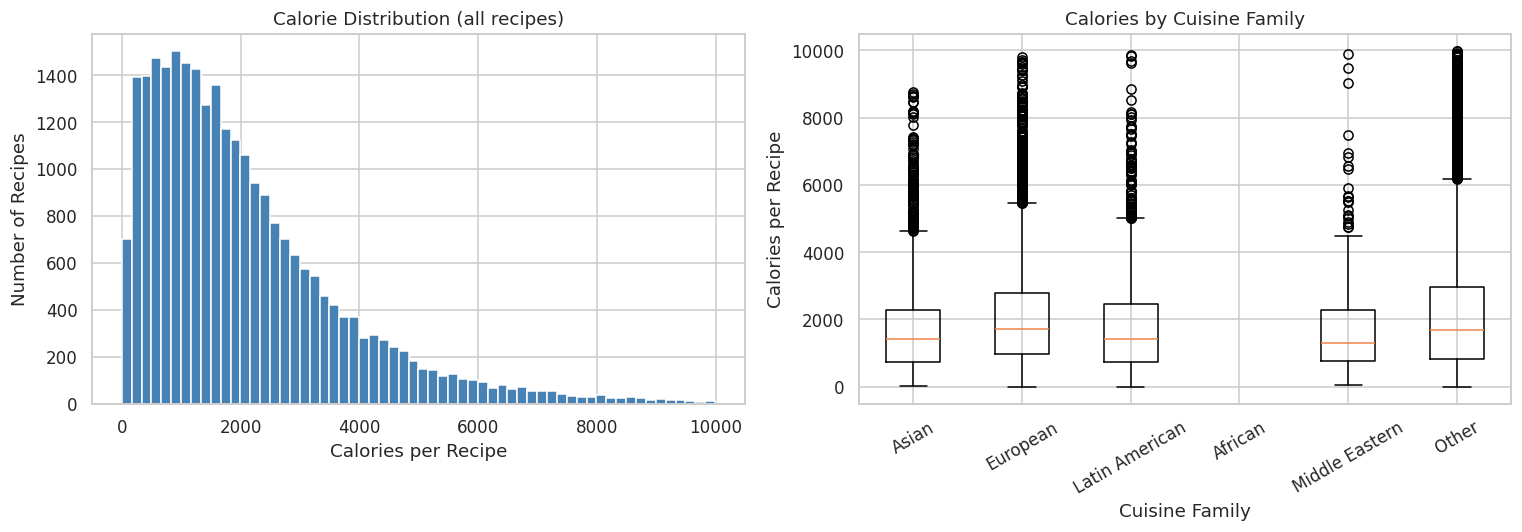

Plot saved to data/processed/calorie_distribution.png


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Histogram of calories per serving (full training set)
axes[0].hist(train_df["calories_per_serving"].dropna(), bins=60, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Calories per Serving")
axes[0].set_ylabel("Number of Recipes")
axes[0].set_title("Calorie Distribution (all recipes)")

# Right: Box plot of calories by cuisine family
# (families with no recipes, such as African here, are left out)
all_families = ["Asian", "European", "Latin American", "African", "Middle Eastern", "Other"]
families = [f for f in all_families if (train_df["cuisine_family"] == f).any()]
data_by_family = [
    train_df[train_df["cuisine_family"] == f]["calories_per_serving"].dropna().values
    for f in families
]
axes[1].boxplot(data_by_family, vert=True)
axes[1].set_xticks(range(1, len(families) + 1))
axes[1].set_xticklabels(families)
axes[1].set_xlabel("Cuisine Family")
axes[1].set_ylabel("Calories per Serving")
axes[1].set_title("Calories per Serving by Cuisine Family")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("data/processed/calorie_distribution.png", bbox_inches="tight")
plt.show()
print("Plot saved to data/processed/calorie_distribution.png")

In [36]:
# Numeric summary of calories by cuisine family
print("Calorie statistics by cuisine family (training set):")
print(
    train_df.groupby("cuisine_family")["calories_per_serving"]
    .agg(["count", "mean", "median", "std"])
    .round(1)
    .to_string()
)

Calorie statistics by cuisine family (training set):
                count    mean  median     std
cuisine_family                               
Asian            2252  1745.5  1409.3  1405.5
European         7627  2083.6  1715.8  1515.1
Latin American   2022  1809.1  1412.2  1494.2
Middle Eastern    479  1720.4  1306.1  1411.8
Other           14186  2140.4  1698.4  1750.5


### 6.1.2 Cuisine Coverage

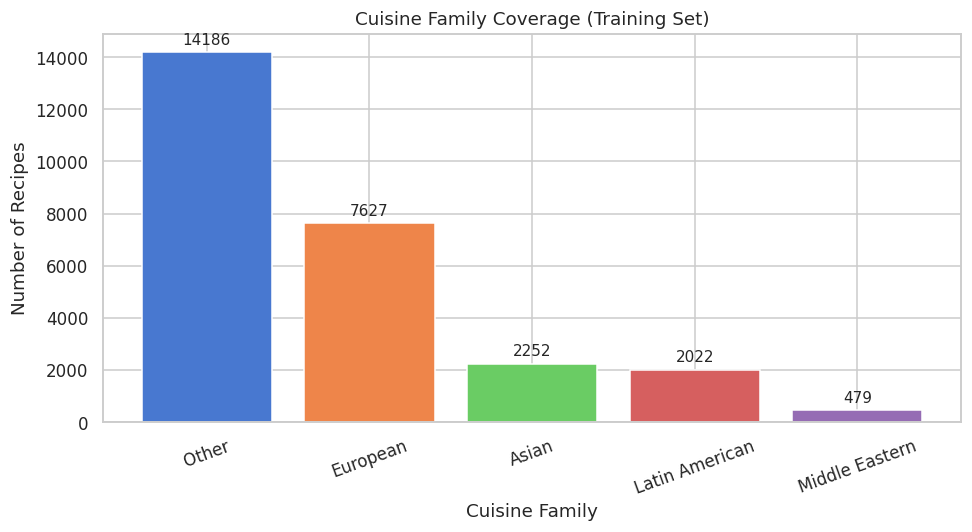


Cuisine counts:
cuisine_family
Other             14186
European           7627
Asian              2252
Latin American     2022
Middle Eastern      479


In [37]:
cuisine_counts = train_df["cuisine_family"].value_counts()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(cuisine_counts.index, cuisine_counts.values, color=sns.color_palette("muted", len(cuisine_counts)))
ax.bar_label(bars, fmt="%d", padding=3, fontsize=10)
ax.set_xlabel("Cuisine Family")
ax.set_ylabel("Number of Recipes")
ax.set_title("Cuisine Family Coverage (Training Set)")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig("data/processed/cuisine_coverage.png", bbox_inches="tight")
plt.show()

print("\nCuisine counts:")
print(cuisine_counts.to_string())

### 6.1.3 Most Frequent Ingredients (Food.com)

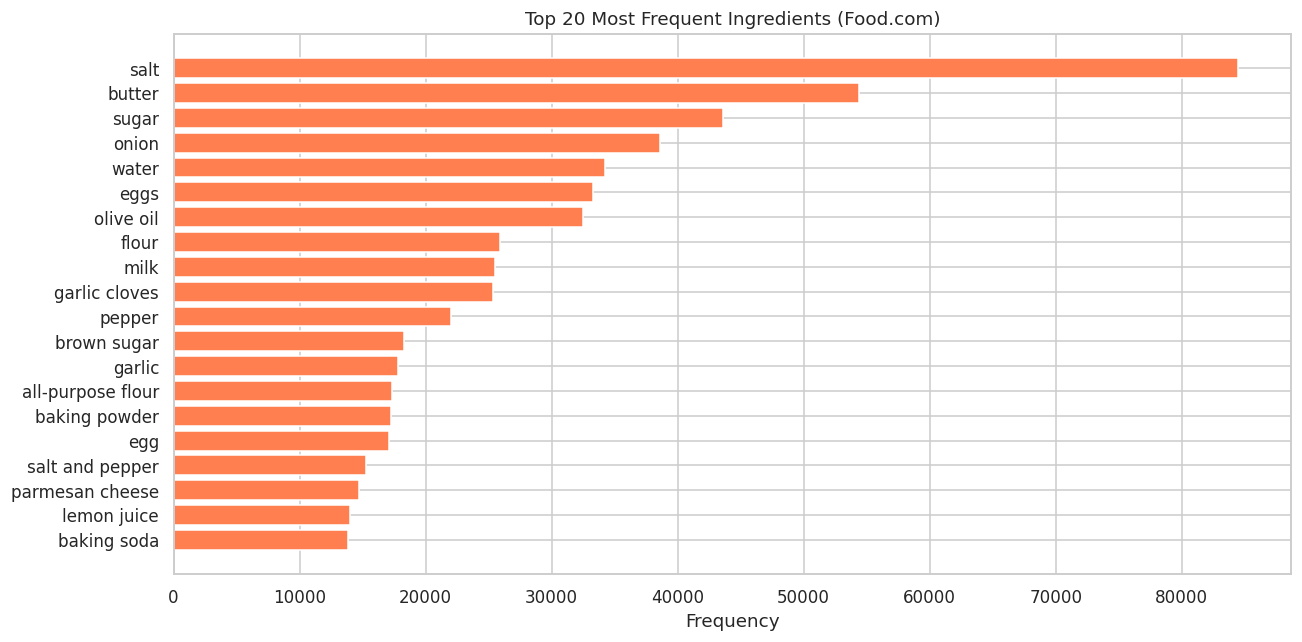


Top 20 ingredients:
  salt                           84,480
  butter                         54,380
  sugar                          43,621
  onion                          38,583
  water                          34,254
  eggs                           33,289
  olive oil                      32,455
  flour                          25,936
  milk                           25,477
  garlic cloves                  25,350
  pepper                         22,040
  brown sugar                    18,307
  garlic                         17,794
  all-purpose flour              17,365
  baking powder                  17,241
  egg                            17,093
  salt and pepper                15,278
  parmesan cheese                14,691
  lemon juice                    13,994
  baking soda                    13,869


In [38]:
# Flatten all ingredient lists into a single list of tokens
try:
    _ = df_fc_clean
except NameError:
    df_fc_clean = pd.read_csv("data/interim/food_com_clean.csv")
    df_fc_clean["ingredient_list"] = df_fc_clean["ingredient_list"].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else []
    )

all_ingredients = []
for lst in df_fc_clean["ingredient_list"]:
    if isinstance(lst, list):
        all_ingredients.extend(lst)

top_ingredients = Counter(all_ingredients).most_common(20)
names, counts = zip(*top_ingredients)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(names[::-1], counts[::-1], color="coral")
ax.set_xlabel("Frequency")
ax.set_title("Top 20 Most Frequent Ingredients (Food.com)")
plt.tight_layout()
plt.savefig("data/processed/top_ingredients.png", bbox_inches="tight")
plt.show()

print("\nTop 20 ingredients:")
for name, count in top_ingredients:
    print(f"  {name:30s} {count:,}")

### 6.1.4 Recipe Complexity Distribution

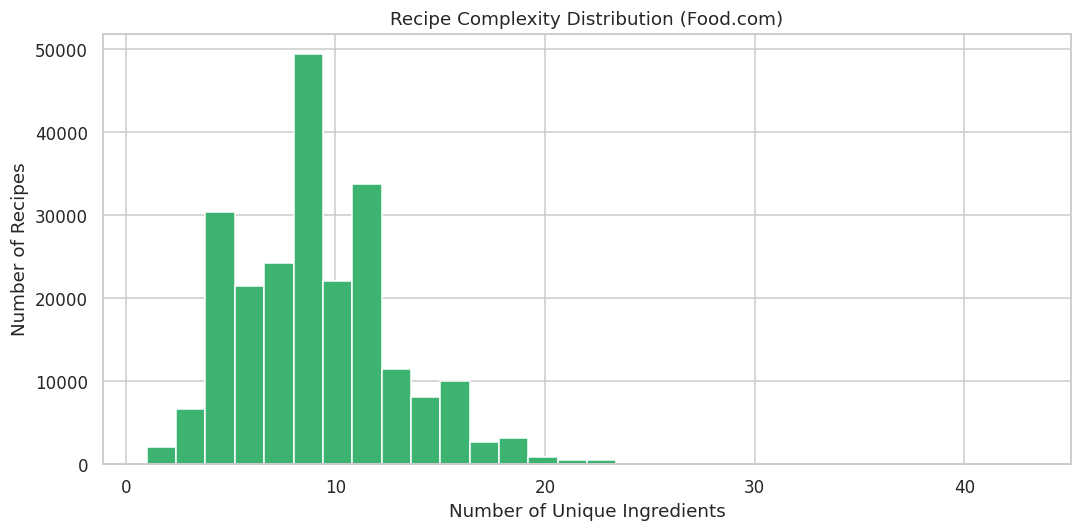

Complexity statistics:
count    228194.000000
mean          9.050698
std           3.730021
min           1.000000
25%           6.000000
50%           9.000000
75%          11.000000
max          43.000000
Name: complexity, dtype: float64


In [39]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_fc_clean["complexity"].dropna(), bins=30, color="mediumseagreen", edgecolor="white")
ax.set_xlabel("Number of Unique Ingredients")
ax.set_ylabel("Number of Recipes")
ax.set_title("Recipe Complexity Distribution (Food.com)")
plt.tight_layout()
plt.savefig("data/processed/complexity_distribution.png", bbox_inches="tight")
plt.show()

print("Complexity statistics:")
print(df_fc_clean["complexity"].describe())

## 6.2 Pattern Identification

Based on the analysis above, we identify the following key patterns and data challenges.

In [40]:
print("=" * 60)
print("KEY PATTERNS AND DATA CHALLENGES")
print("=" * 60)

# Pattern 1: Uneven cuisine coverage
dominant = cuisine_counts.idxmax()
dominant_pct = cuisine_counts.max() / cuisine_counts.sum() * 100
african_n = cuisine_counts.get("African", 0)
mideast_n = cuisine_counts.get("Middle Eastern", 0)
mideast_pct = mideast_n / cuisine_counts.sum() * 100
print(f"\n1. UNEVEN CUISINE COVERAGE")
print(f"   '{dominant}' is the largest group at {dominant_pct:.1f}% of training recipes.")
print(f"   African recipes: {african_n:,} (the dataset has no African cuisine label).")
print(f"   Middle Eastern recipes: {mideast_n:,} ({mideast_pct:.1f}%).")
print(f"   Action: Add African data (e.g. CulinaryDB / RecipeDB) and oversample minority classes.")

# Pattern 2: Missing cuisine labels in Food.com
print(f"\n2. MISSING CUISINE LABELS (Food.com)")
print(f"   Food.com has no direct cuisine column. Tags must be parsed to infer cuisine.")
print(f"   Action: Build a tag-to-cuisine mapping using the 'tags' column.")

# Pattern 3: Calorie outliers
q99 = train_df["calories_per_serving"].quantile(0.99)
print(f"\n3. CALORIE OUTLIERS")
print(f"   Hugging Face calories were whole-recipe totals; they are now divided by servings.")
print(f"   Recipes above {MAX_KCAL_PER_SERVING:,} kcal per serving were removed from both datasets.")
print(f"   99th percentile is now {q99:,.0f} kcal per serving.")
print(f"   Action: Review the remaining high values; some 'servings' fields may be wrong.")

# Pattern 4: Ingredient name variation
print(f"\n4. INGREDIENT NAME VARIATION")
print(f"   Synonyms exist (e.g., 'courgette' vs 'zucchini', 'coriander' vs 'cilantro').")
print(f"   Action: Build an ingredient synonym dictionary for normalization.")

# Pattern 5: Nutrition data completeness
hf_cal_missing = df_hf_clean["calories_per_serving"].isnull().mean() * 100
print(f"\n5. NUTRITION DATA COMPLETENESS")
print(f"   Hugging Face: {hf_cal_missing:.1f}% of rows missing calorie data after cleaning.")
print(f"   Food.com gives calories per serving, but fat, protein, carbs, sugar and sodium")
print(f"   only as percent daily values, not grams.")
print(f"   Action: Convert percent daily values to grams, or backfill macros with the USDA API.")

print("\n" + "=" * 60)

KEY PATTERNS AND DATA CHALLENGES

1. UNEVEN CUISINE COVERAGE
   'Other' accounts for 53.4% of labelled recipes.
   African and Middle Eastern cuisines are likely under-represented.
   Action: May need to oversample or augment minority cuisine classes.

2. MISSING CUISINE LABELS (Food.com)
   Food.com has no direct cuisine column. Tags must be parsed to infer cuisine.
   Action: Build a tag-to-cuisine mapping using the 'tags' column.

3. CALORIE OUTLIERS
   99th percentile calorie value is 7,784 kcal.
   Outliers may represent full-batch recipes, not single-serving amounts.
   Action: Flag and normalize multi-serving recipes using the 'servings' field.

4. INGREDIENT NAME VARIATION
   Synonyms exist (e.g., 'courgette' vs 'zucchini', 'coriander' vs 'cilantro').
   Action: Build an ingredient synonym dictionary for normalization.

5. NUTRITION DATA COMPLETENESS
   Hugging Face: 0.0% of rows missing calorie data after cleaning.
   Food.com has calorie info but only as percent daily values,

## 6.3 Simple Baseline Model

Before building a sophisticated recommendation engine, we establish a rule-based baseline. The baseline logic is:

1. Filter recipes by cuisine family.
2. Apply dietary restriction filters (e.g., vegetarian only).
3. Rank the remaining recipes by how close their calorie count is to the user's target.
4. Return the top N results.

This baseline directly mirrors the core task of the Nutritionist Agent and gives us a measurable starting point to improve on.

In [41]:
def baseline_recommend(
    df,
    cuisine_family=None,
    calorie_target=500,
    vegetarian_only=False,
    vegan_only=False,
    gluten_free=False,
    top_n=5
):
    """Simple rule-based recipe recommender (baseline model).

    Filters by cuisine and dietary flags, then ranks by
    proximity to the calorie target.

    Args:
        df (pd.DataFrame): The preprocessed recipe dataframe.
        cuisine_family (str | None): One of the five EverFlavor families, or None for all.
        calorie_target (float): Desired calories per serving.
        vegetarian_only (bool): Restrict to vegetarian recipes.
        vegan_only (bool): Restrict to vegan recipes.
        gluten_free (bool): Restrict to gluten-free recipes.
        top_n (int): Number of recommendations to return.

    Returns:
        pd.DataFrame: Top N matching recipes sorted by calorie distance.
    """
    results = df.copy()

    # Step 1: Filter by cuisine family
    if cuisine_family:
        results = results[results["cuisine_family"] == cuisine_family]

    # Step 2: Apply dietary flags
    if vegetarian_only:
        results = results[results["vegetarian"] == True]
    if vegan_only:
        results = results[results["vegan"] == True]
    if gluten_free:
        results = results[results["contains_gluten"] == False]

    # Step 3: Drop rows without calorie data
    results = results.dropna(subset=["calories_per_serving"])

    if results.empty:
        print("No recipes matched the given filters.")
        return pd.DataFrame()

    # Step 4: Rank by distance to calorie target
    results["calorie_distance"] = (results["calories_per_serving"] - calorie_target).abs()
    results = results.sort_values("calorie_distance")

    return results.head(top_n)


# Columns shown for every test below
display_cols = ["recipe_name", "cuisine_family", "calories_per_serving",
                "vegetarian", "calorie_distance"]

# -------------------------------------------------------
# Test the baseline on the training split
# -------------------------------------------------------
print("Baseline Test 1: Asian vegetarian recipes near 400 kcal per serving")
print("-" * 60)
recs = baseline_recommend(
    train_df,
    cuisine_family="Asian",
    calorie_target=400,
    vegetarian_only=True,
    top_n=5
)
if not recs.empty:
    print(recs[display_cols].to_string(index=False))

print()
print("Baseline Test 2: Middle Eastern gluten-free recipes near 600 kcal per serving")
print("-" * 60)
recs2 = baseline_recommend(
    train_df,
    cuisine_family="Middle Eastern",
    calorie_target=600,
    gluten_free=True,
    top_n=5
)
if not recs2.empty:
    print(recs2[display_cols].to_string(index=False))

Baseline Test 1: Asian vegetarian recipes near 400 kcal
------------------------------------------------------------
                                                recipe_name cuisine_family  calories_per_serving  vegetarian  calorie_distance
  This Mango Lassi Is Our Go-To Drink From Morning to Night          Asian            400.466667        True          0.466667
Moringa Leaves Stir-Fry (Thoran) with Grate Coconut recipes          Asian            401.218000        True          1.218000
                         Slow Cooker Asian-Style Short Ribs          Asian            402.734000        True          2.734000
                                Apricot Sauce with Sriracha          Asian            402.914000        True          2.914000
                                              Kohlrabi Slaw          Asian            403.057212        True          3.057212

Baseline Test 2: Middle Eastern gluten-free recipes near 600 kcal
------------------------------------------------------

## 6.4 Key Insights for the Three EverFlavor Agents

Based on the Week 6 analysis, we draw actionable conclusions for each agent.

In [42]:
# Numbers quoted below are computed from the data, not typed in
kcal = train_df["calories_per_serving"].dropna()
kcal_q25, kcal_median, kcal_q75 = kcal.quantile([0.25, 0.5, 0.75])
cx = df_fc_clean["complexity"]
top_4 = ", ".join(name for name, _ in top_ingredients[:4])
african_n = (train_df["cuisine_family"] == "African").sum()
mideast_n = (train_df["cuisine_family"] == "Middle Eastern").sum()

print("=" * 65)
print("INSIGHTS FOR THE THREE EVERFLAVOR AGENTS")
print("=" * 65)

print(f"""
NUTRITIONIST AGENT
------------------
- Calories per serving are right-skewed. Half of the training recipes
  fall between {kcal_q25:,.0f} and {kcal_q75:,.0f} kcal (median {kcal_median:,.0f} kcal).
- Hugging Face calories are converted from whole-recipe totals to
  per serving. Food.com gives calories per serving directly, but other
  nutrients only as percent daily values.
- Dietary flags for the HF dataset come from health labels, checked
  against ingredient keywords. Food.com flags are keyword-based only,
  so the Nutritionist Agent should treat them as approximate.
- USDA API lookup should be the ground truth for any ingredient-level
  nutrition verification.

CHEF AGENT
----------
- The most common ingredients ({top_4}) are generic
  Western staples. Culturally specific ingredients appear less often,
  which will require extra attention when generating authentic recipes.
- Recipe complexity ranges from {cx.min()} to {cx.max()} unique ingredients
  (median {cx.median():.0f}). The Chef Agent should present simpler recipes
  (fewer than 10 ingredients) to beginner users and more complex ones
  to experienced cooks.
- The training set has {african_n:,} African and {mideast_n:,} Middle Eastern recipes.
  The Chef Agent will need supplementary data (CulinaryDB or RecipeDB)
  to give reliable recommendations for those families.

SOURCING AGENT
--------------
- Specialty ingredients (miso paste, tahini, plantain, harissa, etc.)
  are not commonly stocked at general supermarkets.
- The Google Places API integration should use cuisine family as the
  primary search tag (e.g., 'Asian grocery store near me').
- A fallback should suggest online retailers for ingredients that
  are not available locally.
""")
print("=" * 65)

INSIGHTS FOR THE THREE EVERFLAVOR AGENTS

NUTRITIONIST AGENT
------------------
- The calorie distribution is right-skewed. Most recipes fall between
  200-800 kcal, but a long tail of high-calorie recipes exists.
- Calorie data is available for the Hugging Face set but must be
  inferred for Food.com using percent daily value columns.
- Dietary restriction flags (vegetarian, vegan, gluten-free, dairy-free)
  are reliable for the HF dataset but keyword-based for Food.com.
  The Nutritionist Agent should treat Food.com flags as approximate.
- USDA API lookup should be the ground truth for any ingredient-level
  nutrition verification.

CHEF AGENT
----------
- The most common ingredients (salt, butter, eggs, flour) are generic
  Western staples. Culturally specific ingredients appear less often,
  which will require extra attention when generating authentic recipes.
- Recipe complexity ranges from 1 to 30+ ingredients. The Chef Agent
  should present simpler recipes (fewer than 10 ingred

## 6.5 Final Dataset Summary

In [43]:
# Week 4 samples are counted from the saved files so this cell
# reports what was actually collected
def saved_rows(csv_path):
    """Return the saved CSV as a dataframe, or an empty one if it is missing."""
    return pd.read_csv(csv_path) if os.path.exists(csv_path) else pd.DataFrame()

usda_saved = saved_rows("data/raw/usda_sample.csv")
off_saved  = saved_rows("data/raw/open_food_facts_sample.csv")
off_queries_with_results = off_saved["search_query"].nunique() if not off_saved.empty else 0

print("=" * 65)
print("FINAL PREPROCESSED DATASET SUMMARY")
print("=" * 65)

print(f"""
FOOD.COM (Primary Recipe Dataset)
  Total recipes (after cleaning): {len(df_fc_clean):,}
  Columns                       : {df_fc_clean.shape[1]}
  Key features added            : ingredient_list, complexity,
                                  calories_per_serving, dietary flags
  Cuisine labels available      : No (must be parsed from tags)
  Saved to                      : data/interim/food_com_clean.csv

HUGGING FACE - Recipes with Nutrition
  Train set                     : {len(train_df):,} rows
  Validation set                : {len(val_df):,} rows
  Test set                      : {len(test_df):,} rows
  Cuisine families represented  : {train_df['cuisine_family'].nunique()}
  Key features added            : cuisine_family, calories_per_serving,
                                  dietary flags, ingredient_list, complexity
  Saved to                      : data/processed/hf_train.csv,
                                  hf_val.csv, hf_test.csv

USDA SAMPLE
  Ingredients saved             : {len(usda_saved)}
  Saved to                      : data/raw/usda_sample.csv

OPEN FOOD FACTS SAMPLE
  Queries with results          : {off_queries_with_results}
  Product records saved         : {len(off_saved)}
  Saved to                      : data/raw/open_food_facts_sample.csv
""")
print("=" * 65)

FINAL PREPROCESSED DATASET SUMMARY

FOOD.COM (Primary Recipe Dataset)
  Total recipes (after cleaning): 228,194
  Columns                       : 27
  Key features added            : ingredient_list, complexity,
                                  calories_per_serving, dietary flags
  Cuisine labels available      : No (must be parsed from tags)
  Saved to                      : data/interim/food_com_clean.csv

HUGGING FACE - Recipes with Nutrition
  Train set                     : 26,566 rows
  Validation set                : 5,693 rows
  Test set                      : 5,693 rows
  Cuisine families represented  : 5
  Key features added            : cuisine_family, dietary flags,
                                  ingredient_list, complexity
  Saved to                      : data/processed/hf_train.csv,
                                  hf_val.csv, hf_test.csv

USDA SAMPLE
  Ingredients sampled           : 8
  Saved to                      : data/raw/usda_sample.csv

OPEN FOOD FACTS SAMP

---

## Weeks 4-6 Completion Checklist

In [44]:
# Each item can name a file or folder that proves it was done.
# Items with a path are only ticked if that path exists;
# items without one (documentation steps) are ticked by hand.
checklist = [
    # Week 4
    ("WEEK 4", "Identified and documented all data sources", None),
    ("WEEK 4", "Created data/raw, data/interim, data/processed folders", "data/processed"),
    ("WEEK 4", "USDA FoodData Central API connected (key from Colab Secrets or .env)", "data/raw/usda_sample.csv"),
    ("WEEK 4", "USDA ingredient sample saved to data/raw/usda_sample.csv", "data/raw/usda_sample.csv"),
    ("WEEK 4", "Food.com dataset downloaded via kagglehub", None),
    ("WEEK 4", "Food.com 1,000-row sample saved to data/raw/food_com_sample.csv", "data/raw/food_com_sample.csv"),
    ("WEEK 4", "Hugging Face recipes-with-nutrition loaded via datasets library", None),
    ("WEEK 4", "Hugging Face 1,000-row sample saved to data/raw/hf_recipes_sample.csv", "data/raw/hf_recipes_sample.csv"),
    ("WEEK 4", "Open Food Facts fully integrated: search, barcode lookup, quality check, save", "data/raw/open_food_facts_sample.csv"),
    ("WEEK 4", "Open Food Facts sample saved to data/raw/open_food_facts_sample.csv", "data/raw/open_food_facts_sample.csv"),
    ("WEEK 4", "Additional datasets (CulinaryDB, RecipeDB, Google Places) documented", None),
    ("WEEK 4", "Privacy and ethics note written", None),
    # Week 5
    ("WEEK 5", "Missing value and duplicate analysis completed for both datasets", None),
    ("WEEK 5", "Outlier analysis completed (calories per serving, cook time)", None),
    ("WEEK 5", "Data cleaning applied (drop missing, dedup, per-serving calories, cap outliers)", None),
    ("WEEK 5", "cuisine_family label engineered and mapped", None),
    ("WEEK 5", "Dietary restriction flags engineered (pork, gluten, dairy, veg, vegan)", None),
    ("WEEK 5", "Macro nutrients per serving extracted (Food.com)", None),
    ("WEEK 5", "Ingredient lists cleaned and tokenized", None),
    ("WEEK 5", "Recipe complexity feature created", None),
    ("WEEK 5", "Reusable run_pipeline() function built", None),
    ("WEEK 5", "Train/val/test split (70/15/15) stratified by cuisine family", "data/processed/hf_test.csv"),
    ("WEEK 5", "Processed files saved to data/processed/ and data/interim/", "data/interim/food_com_clean.csv"),
    # Week 6
    ("WEEK 6", "Calorie distribution visualized and analyzed", "data/processed/calorie_distribution.png"),
    ("WEEK 6", "Cuisine coverage bar chart created", "data/processed/cuisine_coverage.png"),
    ("WEEK 6", "Top 20 ingredient frequency chart created", "data/processed/top_ingredients.png"),
    ("WEEK 6", "Recipe complexity distribution analyzed", "data/processed/complexity_distribution.png"),
    ("WEEK 6", "Five key data patterns identified", None),
    ("WEEK 6", "Baseline model (filter + calorie ranking) implemented", None),
    ("WEEK 6", "Key insights derived for Nutritionist, Chef, and Sourcing agents", None),
    ("WEEK 6", "Final dataset summary printed", None),
]

current_week = None
completed = 0
for week, item, proof_path in checklist:
    if week != current_week:
        print(f"\n{'=' * 55}")
        print(f"  {week}")
        print(f"{'=' * 55}")
        current_week = week
    done = proof_path is None or os.path.exists(proof_path)
    completed += done
    note = "" if done else f"  (missing: {proof_path})"
    print(f"  [{'x' if done else ' '}] {item}{note}")

print(f"\nTotal items completed: {completed} / {len(checklist)}")
if completed == len(checklist):
    print("\nNotebook complete. Ready for Week 7 - Model Development.")
else:
    print("\nSome items are not done yet. Re-run the cells for the missing files above.")


  WEEK 4
  [x] Identified and documented all data sources
  [x] Created data/raw, data/interim, data/processed folders
  [x] USDA FoodData Central API connected via Colab Secrets
  [x] USDA ingredient sample saved to data/raw/usda_sample.csv
  [x] Food.com dataset downloaded via kagglehub
  [x] Food.com 1,000-row sample saved to data/raw/food_com_sample.csv
  [x] Hugging Face recipes-with-nutrition loaded via datasets library
  [x] Hugging Face 1,000-row sample saved to data/raw/hf_recipes_sample.csv
  [x] Open Food Facts fully integrated: search, barcode lookup, quality check, save
  [x] Open Food Facts sample saved to data/raw/open_food_facts_sample.csv
  [x] Additional datasets (CulinaryDB, RecipeDB, Google Places) documented
  [x] Privacy and ethics note written

  WEEK 5
  [x] Missing value and duplicate analysis completed for both datasets
  [x] Outlier analysis completed (calories, cook time)
  [x] Data cleaning applied (drop missing, dedup, cap outliers)
  [x] cuisine_family l